# Analyze Disaster Permits — Synthetic Control Method

Constructs a synthetic counterfactual for each disaster-affected place using
weighted combinations of other BPS places in the same state. The synthetic
control captures seasonal patterns and regional trends without requiring
explicit seasonal decomposition or regional peer adjustment.

**Inputs:**
- `output/permits_panel.csv` — 444 entries (406 metros + 38 places)
- `output/disaster_config.json` — Event definitions, IA summary, gap info
- `output/bps_place_monthly_panel.csv` — Full BPS place panel (donor pool)

**Steps:**
1. Build same-state donor pool for each treated place
2. Fit synthetic control weights (pre-disaster period)
3. Disaster event plots (actual vs synthetic counterfactual)
4. Stacked event study (±4 years, median response curves)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import json
import re
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

CONFIG_DIR  = PROJECT_DIR / "config"
OUTPUT_DIR  = PROJECT_DIR / "output"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

style_path = PROJECT_DIR / "paper.mplstyle"
if style_path.exists():
    plt.style.use(str(style_path))
    print("Using style:", style_path)
else:
    print("paper.mplstyle not found, using default style")

# Load analysis panel (treated places)
panel = pd.read_csv(OUTPUT_DIR / 'permits_panel.csv')
panel['date'] = pd.to_datetime(
    panel['year'].astype(str) + '-' + panel['month'].astype(str) + '-01')
panel = panel.sort_values(['metro_canonical', 'date']).reset_index(drop=True)

# ── Load place selections from CSVs ──
hurr_csv = pd.read_csv(OUTPUT_DIR / 'hurricane_places.csv',
                        dtype={'place_id': str})
nonhurr_csv = pd.read_csv(CONFIG_DIR / 'nonhurr_place_selections.csv',
                           dtype={'place_id': str})
hurr_csv['place_id'] = hurr_csv['place_id'].str.zfill(8)
nonhurr_csv['place_id'] = nonhurr_csv['place_id'].str.zfill(8)

STATE_FIPS = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT',
    '10':'DE','11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL',
    '18':'IN','19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD',
    '25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE',
    '32':'NV','33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND',
    '39':'OH','40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD',
    '47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV',
    '55':'WI','56':'WY','72':'PR','78':'VI',
}

def make_pseudo_name(bps_name, state_abbr):
    """Convert BPS place name to compact pseudo-metro display name."""
    name = bps_name.strip()
    name = re.sub(r'\s+County\s+Unincorporated\s+Area$', ' Co. (unincorp.)', name)
    name = re.sub(r'(\s+Parish)\s+Unincorporated\s+Area$', r'\1 (unincorp.)', name)
    name = re.sub(r'\s+County$', ' Co.', name)
    name = re.sub(r'\s+township$', ' twp.', name)
    name = re.sub(r'\s+city$', ' (city)', name)
    name = re.sub(r'^San Buenaventura$', 'Ventura', name)
    name = re.sub(r'\s+town$', '', name)
    return f"{name}, {state_abbr}"

# Build PLACE_PSEUDOS
PLACE_PSEUDOS = {}
for _, r in hurr_csv.drop_duplicates('place_id').iterrows():
    st = STATE_FIPS.get(r['place_id'][:2], '??')
    PLACE_PSEUDOS[r['place_id']] = make_pseudo_name(r['place_name'], st)
for _, r in nonhurr_csv.iterrows():
    PLACE_PSEUDOS[r['place_id']] = r['pseudo_name']
pseudo_names = set(PLACE_PSEUDOS.values())

# ── Build event dicts from CSVs ──
# Hurricane events
hurr_events = {}
for _, r in hurr_csv.iterrows():
    pname = PLACE_PSEUDOS[r['place_id']]
    hurr_events.setdefault(pname, []).append(
        (r['hurricane_date'], r['hurricane_name'], None))
for k in hurr_events:
    seen = set()
    deduped = []
    for e in hurr_events[k]:
        key = (e[0], e[1])
        if key not in seen:
            seen.add(key)
            deduped.append(e)
    hurr_events[k] = sorted(deduped)

fire_events = {}
tornado_events = {}
earthquake_events = {}
for _, r in nonhurr_csv.iterrows():
    pname = r['pseudo_name']
    dn = int(r['dn_csv']) if pd.notna(r['dn_csv']) else None
    event = (r['date_csv'], r['disaster'], dn)
    if r['type'] == 'Fire':
        fire_events.setdefault(pname, []).append(event)
    elif r['type'] == 'Tornado':
        tornado_events.setdefault(pname, []).append(event)
    elif r['type'] == 'Earthquake':
        earthquake_events.setdefault(pname, []).append(event)
for d in [fire_events, tornado_events, earthquake_events]:
    for k in d:
        d[k].sort()

# Drop events from 2024 onward — insufficient post-disaster data
EVENT_CUTOFF = '2024-01-01'
for events_dict in [fire_events, hurr_events, tornado_events, earthquake_events]:
    for place in list(events_dict.keys()):
        events_dict[place] = [e for e in events_dict[place] if e[0] < EVENT_CUTOFF]
        if not events_dict[place]:
            del events_dict[place]

# ── Load supplementary data ──
# ia_summary from disaster_config.json (for plot annotations)
ia_summary = {}
_cfg_path = OUTPUT_DIR / 'disaster_config.json'
if _cfg_path.exists():
    with open(_cfg_path) as f:
        _cfg = json.load(f)
    for k, v in _cfg.get('ia_summary', {}).items():
        if '|' in k:
            parts = k.split('|', 1)
            try:
                key = (int(parts[0]), parts[1])
            except ValueError:
                key = k
        else:
            try:
                key = int(k)
            except ValueError:
                key = k
        ia_summary[key] = v

# Disaster dates from FEMA disasters CSV
disasters = pd.read_csv(CONFIG_DIR / 'fema_disasters_by_metro.csv')
for col in ['begin_date', 'end_date', 'declaration_date']:
    disasters[col] = pd.to_datetime(disasters[col], errors='coerce')
disaster_dates = {int(dn): dt for dn, dt in
                  disasters.groupby('disasterNumber')['begin_date'].first().items()}

# ── Detect survey gaps from panel data ──
gap_info = {}
_pseudo_tmp = panel[panel['is_pseudo'] == True]
for pname in PLACE_PSEUDOS.values():
    pdata = _pseudo_tmp[_pseudo_tmp['metro_canonical'] == pname]
    if len(pdata) == 0:
        gap_info[pname] = None
        continue
    dates = set(pdata['date'])
    full_range = pd.date_range(min(dates), max(dates), freq='MS')
    missing = sorted(set(full_range) - dates)
    if len(missing) <= 2:
        gap_info[pname] = None
        continue
    gaps = []
    cs, ce = missing[0], missing[0]
    for i in range(1, len(missing)):
        if (missing[i] - ce).days <= 35:
            ce = missing[i]
        else:
            n = len(pd.date_range(cs, ce, freq='MS'))
            if n >= 6:
                gaps.append({'start': cs.strftime('%Y-%m'),
                             'end': ce.strftime('%Y-%m'), 'months': n})
            cs, ce = missing[i], missing[i]
    n = len(pd.date_range(cs, ce, freq='MS'))
    if n >= 6:
        gaps.append({'start': cs.strftime('%Y-%m'),
                     'end': ce.strftime('%Y-%m'), 'months': n})
    gap_info[pname] = gaps if gaps else None

# ── Load place exclusions (optional file, keyed by place_id) ──
_excl_path = CONFIG_DIR / 'place_exclusions.csv'
EXCLUDED_PLACES = set()      # fully excluded (no events kept)
EXCLUSION_NOTES = {}
EXCLUDED_EVENTS = {}         # place -> list of (date, name) removed
if _excl_path.exists():
    _excl_df = pd.read_csv(_excl_path, dtype={'place_id': str})
    _excl_df['place_id'] = _excl_df['place_id'].str.zfill(8)
    for _, _r in _excl_df[_excl_df['exclude'] == 1].iterrows():
        pname = PLACE_PSEUDOS.get(_r['place_id'])
        if not pname:
            continue
        EXCLUSION_NOTES[pname] = _r.get('notes', '')
        evt_name = str(_r.get('event_name', '')) if pd.notna(_r.get('event_name')) else ''
        evt_date = str(_r.get('event_date', '')) if pd.notna(_r.get('event_date')) else ''
        if evt_name and 'Previous disaster' in str(_r.get('notes', '')):
            # Event-specific exclusion: remove only the named event, keep others
            EXCLUDED_EVENTS.setdefault(pname, []).append((evt_date, evt_name))
        else:
            EXCLUDED_PLACES.add(pname)

# Remove fully-excluded places from event dicts
for d in [fire_events, hurr_events, tornado_events, earthquake_events]:
    for excl in EXCLUDED_PLACES:
        d.pop(excl, None)

# Remove specific excluded events (keep first hurricane, drop second)
for pname, excl_list in EXCLUDED_EVENTS.items():
    if pname in hurr_events:
        excl_names = {e[1] for e in excl_list}
        hurr_events[pname] = [e for e in hurr_events[pname]
                              if e[1] not in excl_names]
        if not hurr_events[pname]:
            del hurr_events[pname]  # no events left

# All events combined (for listing treated places)
all_events = {}
for d in [fire_events, hurr_events, tornado_events, earthquake_events]:
    for k, v in d.items():
        all_events.setdefault(k, []).extend(v)

# Reverse lookup: place name -> place_id
name_to_pid = {v: k for k, v in PLACE_PSEUDOS.items()}

# Display-friendly labels
def display_label(name):
    return (name
            .replace(' Co. (unincorp.)', ' County')
            .replace(' (unincorp.)', '')
            .replace(' (city)', ''))

print(f"Panel: {panel['metro_canonical'].nunique()} entries, {len(panel):,} rows")
print(f"  Pseudo-metros: {panel[panel['is_pseudo']==True]['metro_canonical'].nunique()}")
print(f"Events: {len(fire_events)} fire, {len(hurr_events)} hurricane, "
      f"{len(tornado_events)} tornado, {len(earthquake_events)} earthquake")
print(f"Treated places: {len(all_events)} (events before {EVENT_CUTOFF} only)")
if EXCLUDED_PLACES:
    print(f"Fully excluded: {len(EXCLUDED_PLACES)} places "
          f"({', '.join(sorted(EXCLUDED_PLACES))})")
if EXCLUDED_EVENTS:
    print(f"Event-specific exclusions (first hurricane kept): {len(EXCLUDED_EVENTS)} places")
    for _pn, _evts in sorted(EXCLUDED_EVENTS.items()):
        _kept = hurr_events.get(_pn, [])
        _kept_str = ", ".join(e[1] for e in _kept) if _kept else "none"
        _excl_str = ", ".join(e[1] for e in _evts)
        print(f"  {_pn}: kept={_kept_str}, excluded={_excl_str}")


Using style: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\paper.mplstyle
Panel: 665 entries, 191,036 rows
  Pseudo-metros: 268
Events: 6 fire, 253 hurricane, 2 tornado, 0 earthquake
Treated places: 261 (events before 2024-01-01 only)
Fully excluded: 7 places (Butte Co. (unincorp.), CA, Napa, CA, Paradise, CA, Ridgecrest, CA, Superior, CO, Ventura Co. (unincorp.), CA, Ventura, CA)
Event-specific exclusions (first hurricane kept): 19 places
  Beaumont, TX: kept=Rita, Harvey, excluded=Ike
  Calcasieu Parish (unincorp.), LA: kept=Rita, excluded=Laura
  Charlotte Co. (unincorp.), FL: kept=Tropical Storm Bonnie And Charley, excluded=Ian
  Grand Isle, LA: kept=Katrina, excluded=Ida
  Jefferson Co. (unincorp.), TX: kept=Rita, Harvey, excluded=Ike
  Jefferson Parish (unincorp.), LA: kept=Katrina, excluded=Ida
  Kenner, LA: kept=Katrina, excluded=Ida
  Lake Charles, LA: kept=Rita, excluded=Laura
  Mandeville, LA: kept=Katrina, excluded=Ida
  New Orleans, LA: kept=Katrina, excluded=Ida
  Plaquemin

## Synthetic Control Method

For each disaster-affected place, we construct a **synthetic counterfactual**
from other BPS places in the same state. The synthetic control is a weighted
average of donor places, where the weights are chosen to best match the treated
place's permit series in the pre-disaster period.

**Donor pool**: All BPS places in the same state, excluding the disaster-
affected places. Donors must have data in the same months as the treated
place's pre-disaster observations.

**Fitting**: Minimize ‖y_pre − X_pre · w‖² subject to w ≥ 0, using
non-negative least squares on the top 50 most correlated donors
(by Pearson r on 12-month moving averages). Donors must average
at least 2 permits per month in the pre-period to exclude tiny,
volatile places that can produce unstable counterfactuals.

**Seasonality**: The synthetic control naturally captures seasonal patterns
through the donor weighting — no explicit seasonal decomposition is needed.

In [24]:
# Load raw BPS place panel — filter to relevant states
# Build RELEVANT_STATES from place_pseudos (all states with treated places)
RELEVANT_STATES = set(pid[:2] for pid in PLACE_PSEUDOS.keys())
STATE_FIPS = {
    '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT',
    '10':'DE','11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL',
    '18':'IN','19':'IA','20':'KS','21':'KY','22':'LA','23':'ME','24':'MD',
    '25':'MA','26':'MI','27':'MN','28':'MS','29':'MO','30':'MT','31':'NE',
    '32':'NV','33':'NH','34':'NJ','35':'NM','36':'NY','37':'NC','38':'ND',
    '39':'OH','40':'OK','41':'OR','42':'PA','44':'RI','45':'SC','46':'SD',
    '47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA','54':'WV',
    '55':'WI','56':'WY',
}
STATE_NAMES = {k: v for k, v in STATE_FIPS.items() if k in RELEVANT_STATES}

# Census region mapping (for regional donor pool variants)
CENSUS_REGIONS = {
    'Northeast': ['09','23','25','33','34','36','42','44','50'],
    'Midwest':   ['17','18','19','20','26','27','29','31','38','39','46','55'],
    'South':     ['01','05','10','11','12','13','21','22','24','28','37','40','45','47','48','51','54'],
    'West':      ['02','04','06','08','15','16','30','32','35','41','49','53','56'],
}
STATE_TO_REGION = {}
for region, fips_list in CENSUS_REGIONS.items():
    for fips in fips_list:
        STATE_TO_REGION[fips] = region

# Expand to all states in relevant Census regions
REGIONAL_STATES = set()
for pid in PLACE_PSEUDOS.keys():
    reg = STATE_TO_REGION.get(pid[:2])
    if reg:
        for st in CENSUS_REGIONS[reg]:
            REGIONAL_STATES.add(st)
print(f"Loading BPS place panel ({len(REGIONAL_STATES)} states in relevant Census regions)...")
cols = ['place_id', 'state_code', 'year', 'month', 'units_1', 'place_name']
chunks = []
for chunk in pd.read_csv(OUTPUT_DIR / 'bps_place_monthly_panel.csv',
                         usecols=cols, chunksize=500000):
    chunk['state_fips'] = chunk['place_id'].astype(str).str.zfill(8).str[:2]
    chunk = chunk[chunk['state_fips'].isin(REGIONAL_STATES)]
    chunks.append(chunk)
donors_raw = pd.concat(chunks, ignore_index=True)
donors_raw['date'] = pd.to_datetime(
    donors_raw['year'].astype(str) + '-' + donors_raw['month'].astype(str) + '-01')
donors_raw['pid_str'] = donors_raw['place_id'].astype(str).str.zfill(8)

# Exclude treated places from donor pool
treated_pids = set(PLACE_PSEUDOS.keys())
donor_pool = donors_raw[~donors_raw['pid_str'].isin(treated_pids)].copy()

print(f"Loaded {len(donors_raw):,} rows from {donors_raw['pid_str'].nunique():,} places")
print(f"Donor pool: {donor_pool['pid_str'].nunique():,} places (after excluding treated)")
for st in sorted(RELEVANT_STATES):
    n = donor_pool[donor_pool['state_fips'] == st]['pid_str'].nunique()
    print(f"  {STATE_NAMES[st]}: {n:,} donors")


from scipy.optimize import nnls


def fit_synthetic_control(y_pre, X_pre):
    """Find non-negative weights minimizing ||y_pre - X_pre @ w||^2.

    Uses scipy.optimize.nnls (non-negative least squares). Weights are
    NOT constrained to sum to 1 — this allows the synthetic control to
    match treated places at any scale, not just within the convex hull
    of donor places.
    """
    N = X_pre.shape[1]
    if N == 0:
        return np.array([])
    w, _ = nnls(X_pre, y_pre)
    return w


def build_scm_for_place(place_name, pre_end_date, donor_pool, panel,
                        n_top_donors=200, min_avg_permits=2.0,
                        donor_mode='same_state', treated_pid=None,
                        treated_series=None):
    """Build synthetic control for one treated place.

    Fits weights on 12-month moving averages (smoothed data) to focus on
    trend matching rather than monthly noise. Applies the fitted weights
    to both raw and MA series for visualization.

    Parameters
    ----------
    place_name : str
        Name matching metro_canonical in panel.
    pre_end_date : pd.Timestamp
        Last month before disaster (exclusive).
    donor_pool : DataFrame
        Raw BPS data for potential donors.
    panel : DataFrame
        Analysis panel with treated place data.
    n_top_donors : int
        Number of most-correlated donors to keep.

    Returns
    -------
    dict with keys: weights, donor_ids, donor_names, r2,
         synthetic (raw), synthetic_ma, actual, actual_ma,
         pre_end, n_donors_eligible, or None if fitting fails.
    """
    # Handle placebo mode (treated_pid + treated_series provided)
    if treated_pid is not None and treated_series is not None:
        pid = treated_pid
        state = pid[:2]
        actual_raw = treated_series.copy()
        all_dates = sorted(actual_raw.index)
        pre_end_ts = pd.Timestamp(pre_end_date)
        pre_dates = sorted([d for d in all_dates if pd.Timestamp(d) < pre_end_ts])
    else:
        pid = name_to_pid.get(place_name)
        if not pid:
            return None
        state = pid[:2]

        # Get treated place's actual data
        treated = panel[panel['metro_canonical'] == place_name].sort_values('date')
        if len(treated) == 0:
            return None

        # All dates for this place
        all_dates = sorted(treated['date'].values)
        # Treated place raw monthly series
        place_data = panel[panel['metro_canonical'] == place_name].copy()
        
        # FIX: remove duplicate date labels by aggregating permits within each month
        actual_raw = (
            place_data
            .groupby('date', as_index=True)['units_1']
            .sum()
            .sort_index()
            .astype(float)
        )

        # Pre-disaster dates
        pre_end_ts = pd.Timestamp(pre_end_date)
        pre_dates = sorted([d for d in all_dates if pd.Timestamp(d) < pre_end_ts])

    if len(pre_dates) < 24:  # need 24 months for 12-mo MA + fitting
        return None

    pre_date_set = set(pre_dates)

    # Filter donors by donor_mode
    if donor_mode == 'same_state':
        filtered_donors = donor_pool[donor_pool['state_fips'] == state]
    elif donor_mode == 'same_region':
        region = STATE_TO_REGION.get(state, '')
        region_states = set(CENSUS_REGIONS.get(region, []))
        filtered_donors = donor_pool[donor_pool['state_fips'].isin(region_states)]
    elif donor_mode == 'regional_excl_state':
        region = STATE_TO_REGION.get(state, '')
        region_states = set(CENSUS_REGIONS.get(region, [])) - {state}
        filtered_donors = donor_pool[donor_pool['state_fips'].isin(region_states)]
    else:
        filtered_donors = donor_pool[donor_pool['state_fips'] == state]

    # Exclude treated place from donor pool (important for placebos)
    if treated_pid is not None:
        filtered_donors = filtered_donors[filtered_donors['pid_str'] != treated_pid]

    state_donors = filtered_donors  # keep downstream variable name

    # Require donors to cover the full pre-period AND post-treatment
    # (4 years or end of study period, whichever is earlier)
    data_end = pd.Timestamp(max(all_dates))
    post_end = min(pre_end_ts + pd.DateOffset(months=48), data_end)
    post_months = set(pd.date_range(pre_end_ts, post_end, freq='MS'))
    required_dates = sorted(pre_date_set | post_months)
    donor_in_window = state_donors[state_donors['date'].isin(required_dates)]
    donor_coverage = donor_in_window.groupby('pid_str')['date'].nunique()
    eligible = donor_coverage[donor_coverage == len(required_dates)].index.tolist()

    if len(eligible) < 3:
        return None

    # Build raw pre-period matrices
    y_raw = actual_raw.reindex(pre_dates).astype(float)

    donor_pre_data = state_donors[state_donors['date'].isin(pre_date_set) & state_donors['pid_str'].isin(eligible)]
    donor_pivot_raw = donor_pre_data.pivot_table(
        index='date', columns='pid_str', values='units_1', aggfunc='sum')
    donor_pivot_raw = donor_pivot_raw.reindex(pre_dates)

    # Drop donors with NaN or zero variance
    donor_pivot_raw = donor_pivot_raw.dropna(axis=1)
    variances = donor_pivot_raw.var()
    donor_pivot_raw = donor_pivot_raw.loc[:, variances > 0]

    # Filter out tiny donors: require average >= min_avg_permits in pre-period
    donor_means = donor_pivot_raw.mean()
    donor_pivot_raw = donor_pivot_raw.loc[:, donor_means >= min_avg_permits]
    eligible = donor_pivot_raw.columns.tolist()

    if len(eligible) < 3:
        return None

    # Compute 12-month MA for treated and all donors
    y_ma = y_raw.rolling(12, min_periods=12).mean()
    X_ma = donor_pivot_raw.rolling(12, min_periods=12).mean()

    # Drop the first 11 rows (NaN from rolling)
    valid_ma = y_ma.notna()
    y_ma_clean = y_ma[valid_ma].values
    X_ma_clean = X_ma[valid_ma].values

    if len(y_ma_clean) < 12:
        return None

    # Drop any donors with NaN in MA
    col_valid = ~np.isnan(X_ma_clean).any(axis=0)
    X_ma_clean = X_ma_clean[:, col_valid]
    eligible = [eligible[j] for j, v in enumerate(col_valid) if v]

    if len(eligible) < 3:
        return None

    # Pre-filter: top n_top_donors by correlation on MA series
    if len(eligible) > n_top_donors:
        y_std = y_ma_clean.std()
        if y_std > 0:
            corrs = np.array([np.corrcoef(y_ma_clean, X_ma_clean[:, j])[0, 1]
                              for j in range(X_ma_clean.shape[1])])
            corrs = np.nan_to_num(corrs, nan=-1)
        else:
            y_mean = y_ma_clean.mean()
            corrs = -np.abs(X_ma_clean.mean(axis=0) - y_mean)
        top_idx = np.argsort(corrs)[-n_top_donors:]
        eligible = [eligible[j] for j in top_idx]
        X_ma_clean = X_ma_clean[:, top_idx]

    # Fit weights on MA data
    weights = fit_synthetic_control(y_ma_clean, X_ma_clean)

    # Pre-period R²
    y_hat = X_ma_clean @ weights
    ss_res = np.sum((y_ma_clean - y_hat) ** 2)
    ss_tot = np.sum((y_ma_clean - y_ma_clean.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    # Full synthetic series on continuous monthly range (donors have no gaps)
    full_monthly = pd.date_range(min(all_dates), max(all_dates), freq='MS')
    full_donor = state_donors[
        state_donors['pid_str'].isin(eligible) &
        state_donors['date'].isin(full_monthly)]
    full_pivot = full_donor.pivot_table(
        index='date', columns='pid_str', values='units_1', aggfunc='sum')
    full_pivot = full_pivot.reindex(columns=eligible).reindex(full_monthly)

    # Compute raw synthetic (rescale if donors missing, NaN if >50% weight lost)
    total_weight = weights.sum()
    synthetic_raw = np.full(len(full_monthly), np.nan)
    for t_idx, dt in enumerate(full_monthly):
        row = full_pivot.loc[dt]
        valid = row.notna()
        if valid.sum() == 0:
            continue
        w_valid = weights[valid.values]
        w_sum = w_valid.sum()
        if w_sum > 0 and total_weight > 0:
            if w_sum / total_weight < 0.5:
                continue  # too much weight missing, leave as NaN
            scale = total_weight / w_sum
            synthetic_raw[t_idx] = (row[valid].values * w_valid).sum() * scale

    synthetic_series = pd.Series(synthetic_raw, index=full_monthly)

    # Compute MAs: actual on observed dates, synthetic on full monthly range
    actual_ma = actual_raw.rolling(12, min_periods=12).mean()
    synthetic_ma = synthetic_series.rolling(12, min_periods=12).mean()

    # Donor names for reporting
    donor_names_map = (donor_pool[donor_pool['pid_str'].isin(eligible)]
                       .groupby('pid_str')['place_name'].first())

    # RMSPE on reconstructed synthetic MA (standard SCM metric, Abadie et al. 2010)
    pre_act_ma = actual_ma[actual_ma.index < pre_end_date].dropna()
    pre_syn_ma = synthetic_ma.reindex(pre_act_ma.index).dropna()
    common_idx = pre_act_ma.index.intersection(pre_syn_ma.index)
    if len(common_idx) > 0:
        y_rmspe = pre_act_ma[common_idx].values
        s_rmspe = pre_syn_ma[common_idx].values
        rmspe = np.sqrt(np.mean((y_rmspe - s_rmspe) ** 2))
        mean_pre = y_rmspe.mean()
        rmspe_pct = rmspe / mean_pre * 100 if mean_pre > 0 else np.nan
    else:
        rmspe, rmspe_pct = np.nan, np.nan

    return {
        'weights': weights,
        'donor_ids': eligible,
        'donor_names': [donor_names_map.get(d, d) for d in eligible],
        'r2': r2,
        'rmspe': rmspe,
        'rmspe_pct': rmspe_pct,
        'synthetic': synthetic_series,
        'synthetic_ma': synthetic_ma,
        'actual': actual_raw,
        'actual_ma': actual_ma,
        'pre_end': pre_end_date,
        'n_donors_eligible': len(eligible),
    }

print("SCM functions defined.")

Loading BPS place panel (51 states in relevant Census regions)...
Loaded 3,277,882 rows from 21,009 places
Donor pool: 21,009 places (after excluding treated)
  AL: 289 donors
  CA: 528 donors
  CO: 273 donors
  FL: 408 donors
  HI: 4 donors
  LA: 227 donors
  MS: 241 donors
  MO: 586 donors
  NJ: 566 donors
  NY: 1,370 donors
  NC: 255 donors
  OK: 289 donors
  TX: 1,001 donors
SCM functions defined.


In [25]:
# Fit synthetic control for each treated place
# Uses pickle cache to skip re-fitting when inputs haven't changed.
# Delete output/scm_fits.pkl to force re-fitting.
import pickle

SCM_CACHE = OUTPUT_DIR / 'scm_fits.pkl'

if SCM_CACHE.exists():
    with open(SCM_CACHE, 'rb') as f:
        scm_results = pickle.load(f)
    print(f'Loaded {len(scm_results)} SCM fits from cache ({SCM_CACHE.name})')
    print(f'  Delete {SCM_CACHE} to force re-fitting')
    # Summary table
    print(f"\n{'Place':<35s} {'RMSPE%':>7s} {'R²':>6s} {'w_sum':>7s}")
    print('-' * 60)
    for name in sorted(scm_results.keys(), key=lambda n: scm_results[n]['rmspe_pct']):
        res = scm_results[name]
        ws = res['weights'].sum()
        print(f"  {display_label(name):<33s} {res['rmspe_pct']:>6.1f}% {res['r2']:>6.3f} {ws:>7.2f}")
else:
    scm_results = {}
    skipped = []

    for place_name in sorted(all_events.keys()):
        events = all_events[place_name]
        earliest = pd.Timestamp(min(e[0] for e in events))

        result = build_scm_for_place(place_name, earliest, donor_pool, panel,
                                     donor_mode='regional_excl_state')

        if result is None:
            skipped.append(place_name)
            print(f"  SKIP {place_name}: insufficient pre-disaster data or donors")
        else:
            scm_results[place_name] = result
            w = result['weights']
            w_total = w.sum()
            w_rel = w / w_total if w_total > 0 else w
            top3_w = sorted(zip(w_rel, result['donor_names']),
                            reverse=True)[:3]
            top3_str = ', '.join(f'{n} ({r:.0%})' for r, n in top3_w)
            print(f"  {display_label(place_name)}: RMSPE%={result['rmspe_pct']:.1f}%, "
                  f"w_sum={w_total:.2f}, "
                  f"{result['n_donors_eligible']} donors, top: {top3_str}")

    print(f"\nFitted: {len(scm_results)} / {len(all_events)} places")
    if skipped:
        print(f"Skipped: {', '.join(display_label(s) for s in skipped)}")

    # Save cache
    with open(SCM_CACHE, 'wb') as f:
        pickle.dump(scm_results, f)
    print(f'\nSaved SCM fits to {SCM_CACHE.name}')

    # Summary table sorted by RMSPE%
    print(f"\n{'Place':<35s} {'RMSPE%':>7s} {'R²':>6s} {'w_sum':>7s}")
    print('-' * 60)
    for name in sorted(scm_results.keys(), key=lambda n: scm_results[n]['rmspe_pct']):
        res = scm_results[name]
        w = res['weights']
        ws = w.sum()
        print(f"  {display_label(name):<33s} {res['rmspe_pct']:>6.1f}% {res['r2']:>6.3f} {ws:>7.2f}")


  Aberdeen twp., NJ: RMSPE%=33.7%, w_sum=0.72, 200 donors, top: East Marlborough township (33%), Duxbury town (27%), Abington town (18%)
  Acadia Parish, LA: RMSPE%=2.4%, w_sum=2.04, 200 donors, top: Joshua (18%), Cold Spring (16%), Union County (14%)
  Addis, LA: RMSPE%=31.3%, w_sum=1.04, 200 donors, top: Lake Alfred (62%), Davenport (35%), Loudon County Unincorporated Area (2%)
  Alexandria, LA: RMSPE%=19.7%, w_sum=1.23, 200 donors, top: Senatobia (22%), Ardmore (21%), Cayce (18%)
  Alvin, TX: RMSPE%=4.2%, w_sum=1.12, 200 donors, top: Greenbrier (20%), Morristown (14%), Glades County Unincorporated Area (13%)
  Angleton, TX: RMSPE%=7.4%, w_sum=0.36, 200 donors, top: Prince Edward County Unincorporated Area (24%), Goodlettsville (23%), St. Augustine Beach (19%)
  Ascension Parish, LA: RMSPE%=9.0%, w_sum=4.03, 200 donors, top: Vilonia town (58%), Putnam County Unincorporated Area (16%), Hamilton County Unincorporated Area (7%)
  Assumption Parish, LA: RMSPE%=5.2%, w_sum=1.16, 200 donor

## SCM Fit Quality

We assess fit quality using the root mean square prediction error (RMSPE)
on 12-month moving averages in the pre-disaster period, expressed as a
percentage of mean pre-period permit activity (RMSPE%). This is the
standard SCM fit metric (Abadie, Diamond & Hainmueller 2010, 2015).

The example plots below show actual vs synthetic for a high-activity and
low-activity place during their pre-disaster periods.

Pre-period RMSPE% by place:
  Indian River County, FL             RMSPE% = 0.1%
  Ocean Springs, MS                   RMSPE% = 0.4%
  Foley, AL                           RMSPE% = 0.6%
  Jefferson Davis Parish, LA          RMSPE% = 0.8%
  Charlotte County, FL                RMSPE% = 0.9%
  Escambia County Part Unincorporated Area, FL RMSPE% = 1.0%
  Sulphur, LA                         RMSPE% = 1.0%
  Brevard County, FL                  RMSPE% = 1.1%
  Mobile County, AL                   RMSPE% = 1.1%
  Mandeville, LA                      RMSPE% = 1.1%
  Terrebonne Parish, LA               RMSPE% = 1.2%
  Lafourche Parish, LA                RMSPE% = 1.2%
  Palm Bay, FL                        RMSPE% = 1.3%
  Beaumont, TX                        RMSPE% = 1.3%
  Volusia County, FL                  RMSPE% = 1.3%
  Sebastian, FL                       RMSPE% = 1.4%
  Santa Rosa Co., FL                  RMSPE% = 1.4%
  New Smyrna Beach, FL                RMSPE% = 1.5%
  Deltona, FL              

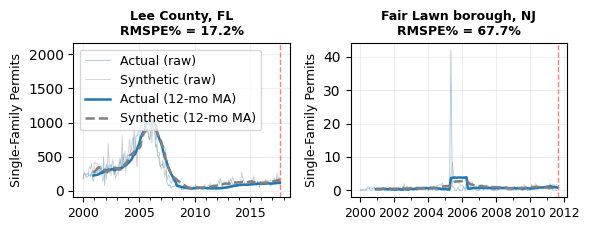

In [28]:
# Summary of fit quality (RMSPE% as primary metric)
rmspe_values = {k: v['rmspe_pct'] for k, v in scm_results.items()}
rmspe_series = pd.Series(rmspe_values).sort_values()

print("Pre-period RMSPE% by place:")
for name, rp in rmspe_series.items():
    flag = " *** POOR FIT" if rp > 30 else ""
    print(f"  {display_label(name):<35s} RMSPE% = {rp:.1f}%{flag}")

print(f"\nMedian RMSPE%: {rmspe_series.median():.1f}%")
print(f"Places with RMSPE% <= 10%: {(rmspe_series <= 10).sum()} / {len(rmspe_series)}")
print(f"Places with RMSPE% > 20%:  {(rmspe_series > 20).sum()} / {len(rmspe_series)}")

# Example plots: high-activity and low-activity place
place_means = {k: v['actual'].mean() for k, v in scm_results.items()}
sorted_by_mean = sorted(place_means.items(), key=lambda x: x[1], reverse=True)
high_place = sorted_by_mean[0][0]
low_place = sorted_by_mean[-1][0]

fig, axes = plt.subplots(1, 2, figsize=(6, 2.4))

for ax, place in zip(axes, [high_place, low_place]):
    res = scm_results[place]

    # Reindex actual to full monthly range (gaps become NaN \u2192 line breaks)
    # Synthetic is already on full monthly range (continuous)
    full_idx = pd.date_range(res['actual'].index.min(),
                             res['actual'].index.max(), freq='MS')
    actual = res['actual'].reindex(full_idx)
    actual_ma = res['actual_ma'].reindex(full_idx)
    synthetic = res['synthetic']
    synthetic_ma = res['synthetic_ma']

    pre_mask_actual = full_idx < res['pre_end']
    pre_mask_synth = synthetic.index < res['pre_end']

    ax.plot(full_idx[pre_mask_actual], actual.values[pre_mask_actual],
            linewidth=0.6, color='C0', alpha=0.4, label='Actual (raw)')
    ax.plot(synthetic.index[pre_mask_synth], synthetic.values[pre_mask_synth],
            linewidth=0.6, color='gray', alpha=0.4, label='Synthetic (raw)')

    # 12-month MA (pre-computed)
    ax.plot(full_idx[pre_mask_actual], actual_ma.values[pre_mask_actual],
            linewidth=1.8, color='C0', label='Actual (12-mo MA)')
    ax.plot(synthetic_ma.index[pre_mask_synth], synthetic_ma.values[pre_mask_synth],
            linewidth=1.8, color='gray', linestyle='--', label='Synthetic (12-mo MA)')

    ax.axvline(res['pre_end'], color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f"{display_label(place)}\nRMSPE% = {res['rmspe_pct']:.1f}%",
                 fontweight='bold', fontsize=9)
    ax.set_ylabel('Single-Family Permits', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    if ax == axes[0]:
        ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.YearLocator())
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_scm_fit_examples.pdf', bbox_inches='tight', dpi=150)
plt.show()

Place                               Type         RMSPE%   Mean  w_sum  NZ   HHI   Excess Post
----------------------------------------------------------------------------------------------------
  Indian River County, FL           Hurricane      0.1%   77.8   8.40  34 0.132     2417     
  Ocean Springs, MS                 Hurricane      0.4%   12.2   0.63  15 0.197      -95     
  Foley, AL                         Hurricane      0.6%   21.2   1.86  21 0.107      352     
  Jefferson Davis Parish, LA        Hurricane      0.8%    5.1   0.39  13 0.163       61     
  Charlotte County, FL              Hurricane      0.9%  118.2   8.19  20 0.103      -61     
  Escambia County Part Unincorporated Area, FL Hurricane      1.0%  125.1   5.02  15 0.174    -2054     
  Sulphur, LA                       Hurricane      1.0%    3.1   0.13  12 0.211       71     
  Brevard County, FL                Hurricane      1.1%  179.5   6.46  15 0.127    -3701     
  Mobile County, AL                 Hurric

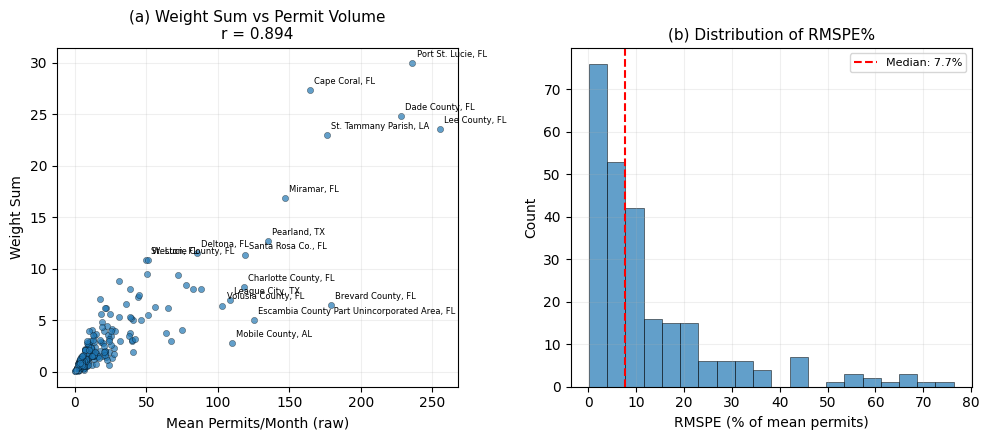

In [31]:
# ── Weight and fit diagnostics ──

diag = []
for name, res in sorted(scm_results.items()):
    w = res['weights']
    actual_ma = res['actual_ma']
    synth_ma = res['synthetic_ma']

    # Pre-period: align actual and synthetic MAs
    pre_mask = actual_ma.index < res['pre_end']
    y_pre = actual_ma[pre_mask].dropna()
    s_pre = synth_ma.reindex(y_pre.index).dropna()
    common = y_pre.index.intersection(s_pre.index)
    y = y_pre[common].values
    s = s_pre[common].values

    # RMSPE on 12-month MA
    rmspe = np.sqrt(np.mean((y - s) ** 2))
    mean_permits = y.mean()
    rmspe_pct = rmspe / mean_permits * 100 if mean_permits > 0 else np.nan

    # Weight diagnostics
    w_sum = w.sum()
    w_max = w.max()
    w_nonzero = int(np.sum(w > 1e-6))
    w_norm = w / w_sum if w_sum > 0 else w
    hhi = float(np.sum(w_norm ** 2))  # 1/N = perfect spread, 1.0 = single donor

    # Mean raw permits (not MA)
    actual_raw_pre = res['actual'][res['actual'].index < res['pre_end']].dropna()
    mean_raw = actual_raw_pre.mean()

    # Disaster type
    if name in fire_events:
        dtype = 'Fire'
    elif name in hurr_events:
        dtype = 'Hurricane'
    elif name in tornado_events:
        dtype = 'Tornado'
    elif name in earthquake_events:
        dtype = 'Earthquake'
    else:
        dtype = 'Unknown'

    # Excess permits: sum of (actual - synthetic) on raw monthly data, first 48 months post
    post_start = res['pre_end']
    post_end_48 = post_start + pd.DateOffset(months=48)
    actual_raw_post = res['actual'][(res['actual'].index >= post_start)
                                    & (res['actual'].index < post_end_48)].dropna()
    synth_raw_post = res['synthetic'].reindex(actual_raw_post.index).dropna()
    common_post = actual_raw_post.index.intersection(synth_raw_post.index)
    n_post_months = len(common_post)
    if n_post_months > 0:
        excess = float((actual_raw_post[common_post] - synth_raw_post[common_post]).sum())
    else:
        excess = np.nan

    diag.append({
        'name': name, 'type': dtype, 'r2': res['r2'], 'rmspe': rmspe,
        'rmspe_pct': rmspe_pct, 'mean_ma': mean_permits,
        'mean_raw': mean_raw, 'w_sum': w_sum, 'w_max': w_max,
        'w_nonzero': w_nonzero, 'hhi': hhi,
        'n_donors': res['n_donors_eligible'],
        'excess_permits': excess,
        'post_months': n_post_months,
    })

diag_df = pd.DataFrame(diag).sort_values('rmspe_pct')

# Dict for passing excess permits to plot titles
excess_permits_dict = dict(zip(diag_df['name'], diag_df['excess_permits']))

# ── Diagnostics table ──
print(f"{'Place':<35s} {'Type':<11s} {'RMSPE%':>7s} "
      f"{'Mean':>6s} {'w_sum':>6s} {'NZ':>3s} {'HHI':>5s} "
      f"{'Excess':>8s} {'Post':>4s}")
print('-' * 100)
for _, row in diag_df.iterrows():
    post_str = f"{row['post_months']:>4d}" if row['post_months'] < 48 else "    "
    print(f"  {display_label(row['name']):<33s} {row['type']:<11s} {row['rmspe_pct']:>6.1f}% "
          f"{row['mean_raw']:>6.1f} {row['w_sum']:>6.2f} "
          f"{row['w_nonzero']:>3d} {row['hhi']:>5.3f} "
          f"{row['excess_permits']:>8.0f} {post_str}")

print(f"\nSummary (71 places):")
print(f"  RMSPE%: median={diag_df['rmspe_pct'].median():.1f}%, "
      f"mean={diag_df['rmspe_pct'].mean():.1f}%, "
      f"max={diag_df['rmspe_pct'].max():.1f}%")
print(f"  R²:     median={diag_df['r2'].median():.3f}, "
      f"min={diag_df['r2'].min():.3f}")
print(f"  Nonzero weights: median={diag_df['w_nonzero'].median():.0f}, "
      f"range={diag_df['w_nonzero'].min():.0f}–{diag_df['w_nonzero'].max():.0f}")
print(f"  HHI: median={diag_df['hhi'].median():.3f}, "
      f"max={diag_df['hhi'].max():.3f} "
      f"(1/{1/diag_df['hhi'].median():.0f} effective donors at median)")

# ── Save diagnostics CSV (subset of columns) ──
csv_cols = ['name', 'type', 'rmspe_pct', 'mean_raw', 'w_sum', 'w_max',
            'w_nonzero', 'hhi', 'excess_permits', 'post_months']
csv_path = FIGURES_DIR.parent / 'output' / 'scm_diagnostics.csv'
diag_df[csv_cols].to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

# ── Figures ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# (a) Scatter: w_sum vs mean permits/month
ax = axes[0]
ax.scatter(diag_df['mean_raw'], diag_df['w_sum'],
           s=20, alpha=0.7, edgecolors='k', linewidth=0.3)
for _, row in diag_df.iterrows():
    if row['w_sum'] > 10 or row['mean_raw'] > 100:
        ax.annotate(display_label(row['name']),
                    (row['mean_raw'], row['w_sum']),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')
r_corr = diag_df['mean_raw'].corr(diag_df['w_sum'])
ax.set_xlabel('Mean Permits/Month (raw)')
ax.set_ylabel('Weight Sum')
ax.set_title(f'(a) Weight Sum vs Permit Volume\nr = {r_corr:.3f}')
ax.grid(True, alpha=0.2)

# (b) Histogram of RMSPE%
ax = axes[1]
ax.hist(diag_df['rmspe_pct'], bins=20, edgecolor='k', linewidth=0.5, alpha=0.7)
ax.axvline(diag_df['rmspe_pct'].median(), color='red', linewidth=1.5,
           linestyle='--', label=f"Median: {diag_df['rmspe_pct'].median():.1f}%")
ax.set_xlabel('RMSPE (% of mean permits)')
ax.set_ylabel('Count')
ax.set_title('(b) Distribution of RMSPE%')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_scm_weight_diagnostics.pdf',
            bbox_inches='tight', dpi=150)
plt.show()


## Disaster Event Analysis

Each subplot shows one disaster-affected place:
- **Thin blue**: Raw monthly actual permits
- **Thin gray**: Raw monthly synthetic control
- **Bold blue**: 12-month moving average of actual
- **Bold gray dashed**: 12-month moving average of synthetic

The synthetic control shows what permits *would have been* without the disaster.
Divergence between actual and synthetic after the disaster date reveals the
disaster's causal impact on building permits.

- **Dashed red/dark red**: Disaster events with IA statistics
- **Orange dotted**: Other FEMA disaster declarations (≥2 counties)

In [34]:
def plot_disaster_events(metro_events_dict, category_label, scm_results,
                         ia_summary, disasters, save_path=None,
                         excluded_events=None, legend_loc='upper right',
                         excess_permits=None):
    """Plot actual vs synthetic control for a group of disaster-affected places."""
    metros = list(metro_events_dict.keys())
    n = len(metros)
    ncols = 2
    nrows = max((n + ncols - 1) // ncols, 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6, 2.4 * nrows))
    if nrows == 1 and ncols > 1:
        axes = axes.reshape(1, -1)
    elif n == 1:
        axes = np.array([[axes]])
    axes_flat = axes.flat

    def _fmt_count(n):
        if n >= 1e6: return f'{n/1e6:.1f}M'
        if n >= 1e3: return f'{n/1e3:.0f}k'
        return str(int(n))

    def _fmt_dollars(n):
        if n >= 1e9: return f'${n/1e9:.1f}B'
        if n >= 1e6: return f'${n/1e6:.0f}M'
        if n >= 1e3: return f'${n/1e3:.0f}k'
        return f'${int(n)}'

    for i, metro in enumerate(metros):
        ax = axes_flat[i]
        events = metro_events_dict[metro]
        res = scm_results.get(metro)

        if res is None:
            ax.text(0.5, 0.5, 'No SCM fit\n(insufficient data)',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=10, color='gray')
            ax.set_title(display_label(metro), fontweight='bold')
            continue

        # Reindex actual to full monthly range so survey gaps become NaN (line breaks)
        # Synthetic is already on full monthly range (donors have no gaps)
        full_idx = pd.date_range(res['actual'].index.min(),
                                 res['actual'].index.max(), freq='MS')
        actual = res['actual'].reindex(full_idx)
        actual_ma = res['actual_ma'].reindex(full_idx)
        synthetic = res['synthetic']
        synthetic_ma = res['synthetic_ma']

        # Truncate synthetic display at earliest event + 8 years
        earliest_event = min(pd.Timestamp(e[0]) for e in events)
        synth_end = earliest_event + pd.DateOffset(years=8)
        synth_mask = synthetic.index <= synth_end

        # Raw monthly — actual (full range with gap breaks), synthetic (truncated, continuous)
        ax.plot(actual.index, actual.values,
                linewidth=0.6, alpha=0.4, color='C0')
        ax.plot(synthetic.index[synth_mask],
                synthetic.values[synth_mask],
                linewidth=0.6, alpha=0.4, color='gray')

        # 12-month MA — actual (full range with gap breaks), synthetic (truncated, continuous)
        synth_ma_mask = synthetic_ma.index <= synth_end
        ax.plot(actual_ma.index, actual_ma.values,
                linewidth=1.8, color='C0', label='Actual')
        ax.plot(synthetic_ma.index[synth_ma_mask],
                synthetic_ma.values[synth_ma_mask],
                linewidth=1.8, color='gray', linestyle='--', label='Synthetic')

        # Disaster event markers + IA annotations
        colors = ['red', 'darkred', 'crimson', 'firebrick']
        for j, (edate, ename, dn) in enumerate(events):
            edt = pd.Timestamp(edate)
            c = colors[j % len(colors)]
            ax.axvline(edt, color=c, linewidth=1.5, linestyle='--', alpha=0.8)

            # ia = ia_summary.get((dn, metro), ia_summary.get(dn, {}))
            # reg = ia.get('registrations', 0)
            # dmg = ia.get('damage_usd', 0)

            # if reg > 0:
            #     elabel = f"{ename}\n{_fmt_count(reg)} reg\n{_fmt_dollars(dmg)}"
            # else:
            #     elabel = ename

            ymin, ymax = ax.get_ylim()
            ypos = ymax - (ymax - ymin) * (0.05 + 0.12 * j)
            ax.text(edt + pd.Timedelta(days=120), ypos,
                    ename, color=c, fontsize=9, va='top', fontweight='bold',
                    linespacing=1.3)

        # Orange dotted lines for other FEMA declarations
        event_dns = [e[2] for e in events]
        other = disasters[
            (disasters['metro_canonical'] == metro) &
            (disasters['n_counties'] >= 2) &
            (~disasters['disasterNumber'].isin(event_dns))]
        for _, dd in other.iterrows():
            ax.axvline(pd.Timestamp(dd['begin_date']), color='orange',
                       linewidth=0.7, linestyle=':', alpha=0.4)

        # Gap shading
        gi = gap_info.get(metro)
        if gi:
            for g in gi:
                gs = pd.Timestamp(g['start'] + '-01')
                ge = pd.Timestamp(g['end'] + '-01') + pd.offsets.MonthEnd(1)
                ax.axvspan(gs, ge, alpha=0.10, color='gray', zorder=0)

        # Excluded event markers (second hurricane for double-event places)
        if excluded_events and metro in excluded_events:
            for edate, ename in excluded_events[metro]:
                edt = pd.Timestamp(edate)
                ax.axvline(edt, color='#7b1fa2', linewidth=1.5,
                           linestyle=':', alpha=0.8)
                ymin, ymax = ax.get_ylim()
                ypos = ymin + (ymax - ymin) * 0.15
                ax.text(edt + pd.Timedelta(days=120), ypos,
                        f'{ename}\n(excluded)',
                        color='#7b1fa2', fontsize=9, va='top',
                        fontweight='bold', fontstyle='italic')

        title = display_label(metro)
        if excess_permits and metro in excess_permits:
            ep = excess_permits[metro]
            if not (isinstance(ep, float) and np.isnan(ep)):
                title += f' (E = {ep:,.0f})'
        ax.set_title(title, fontweight='bold', fontsize=9)
        ax.set_ylabel('Single-Family Permits', fontsize=9)
        ax.grid(True, alpha=0.2)

    # Legend on first visible axis
    for ax in axes_flat:
        if ax.get_visible():
            ax.legend(fontsize=9, loc=legend_loc)
            break

    for j in range(n, nrows * ncols):
        axes_flat[j].set_visible(False)
    for ax in axes.flat:
        if ax.get_visible():
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.xaxis.set_minor_locator(mdates.YearLocator())
            ax.tick_params(axis='x', labelsize=9)

    # fig.suptitle(category_label, y=1.01, fontsize=11)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

print("plot_disaster_events() defined.")

plot_disaster_events() defined.


### Wildfire Places

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17640\2120092027.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc=legend_loc)


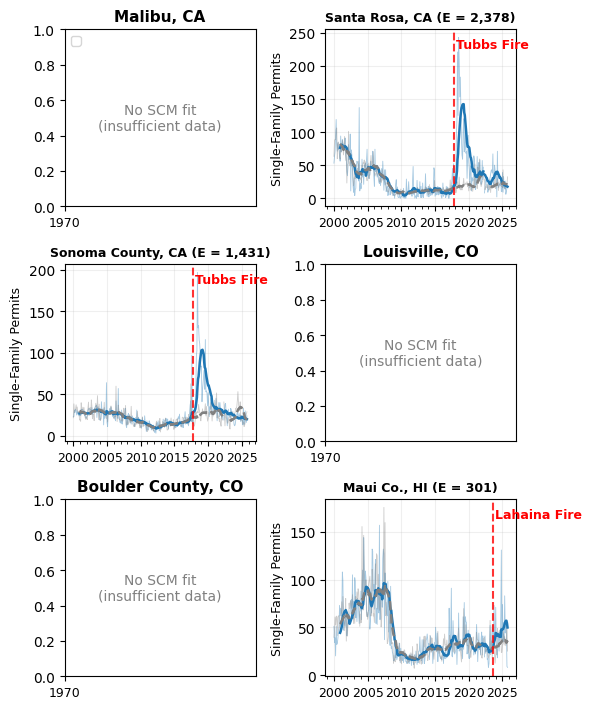

6 fire places, 6 events, 1 figures


In [37]:
fire_items = list(fire_events.items())
max_per_fig = 6
n_fire_figs = max((len(fire_items) + max_per_fig - 1) // max_per_fig, 1)

for fig_idx in range(n_fire_figs):
    start = fig_idx * max_per_fig
    end = min(start + max_per_fig, len(fire_items))
    chunk = dict(fire_items[start:end])
    suffix = chr(ord('a') + fig_idx)
    label = 'Wildfires: Actual vs Synthetic Control'
    if fig_idx > 0:
        label += ' (continued)'
    fname = f'fig_fire_events_place_{suffix}.pdf'
    plot_disaster_events(chunk, label, scm_results, ia_summary, disasters,
                         save_path=FIGURES_DIR / fname, legend_loc='upper left',
                         excess_permits=excess_permits_dict)

print(f"{len(fire_events)} fire places, "
      f"{sum(len(v) for v in fire_events.values())} events, {n_fire_figs} figures")

### Tornado Places

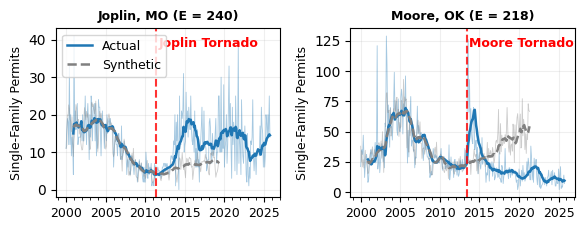

2 tornado places, 2 events


In [40]:
plot_disaster_events(tornado_events,
                     'Tornadoes: Actual vs Synthetic',
                     scm_results, ia_summary, disasters,
                     save_path=FIGURES_DIR / 'fig_tornado_events_place.pdf', legend_loc='upper left',
                     excess_permits=excess_permits_dict)
print(f"{len(tornado_events)} tornado places, {sum(len(v) for v in tornado_events.values())} events")

### Hurricane Places

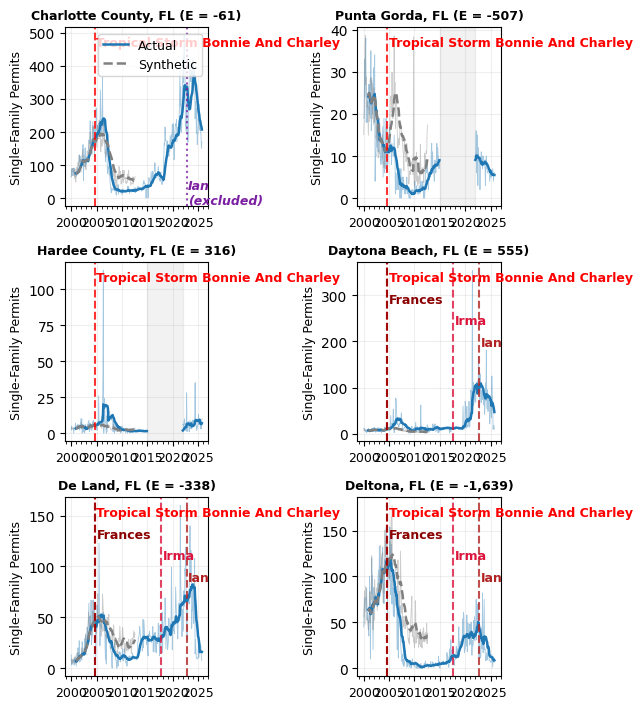

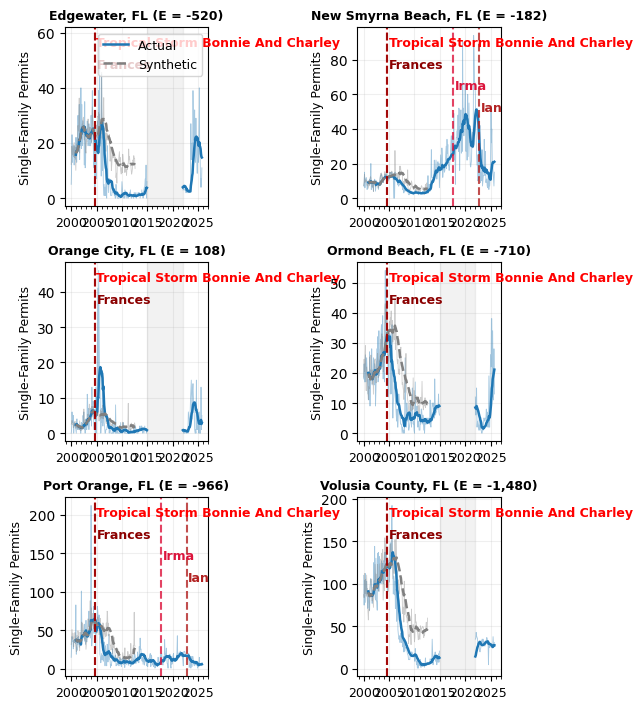

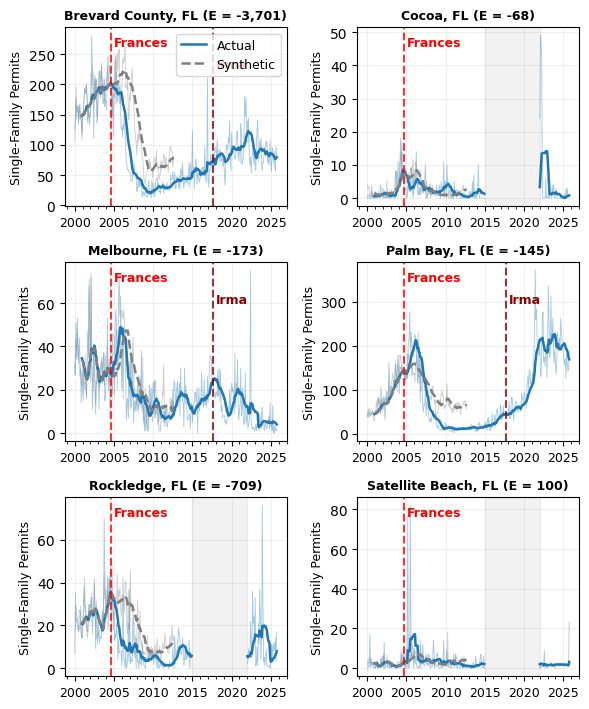

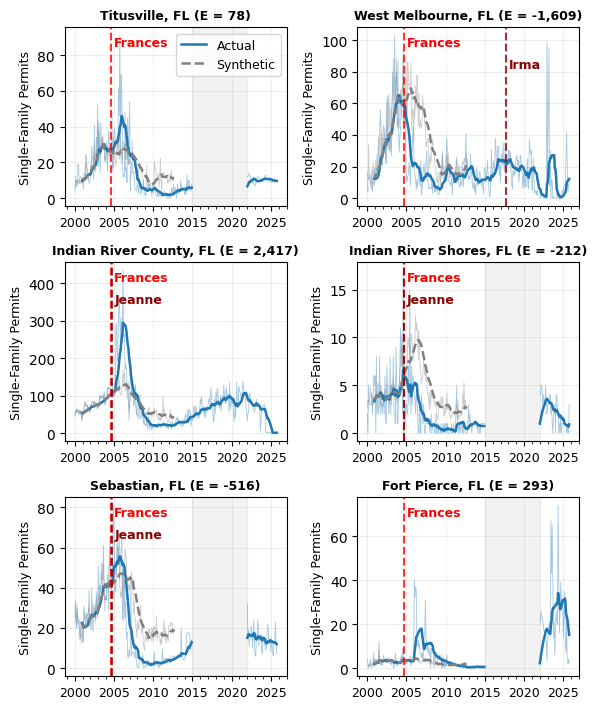

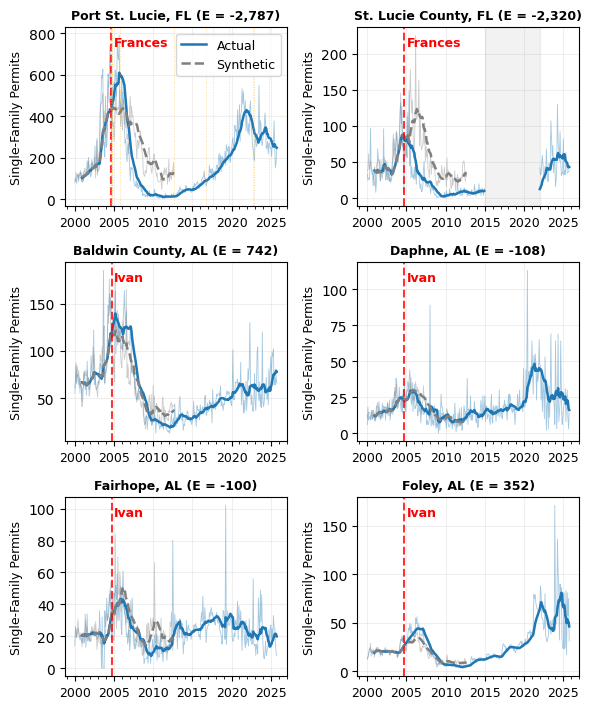

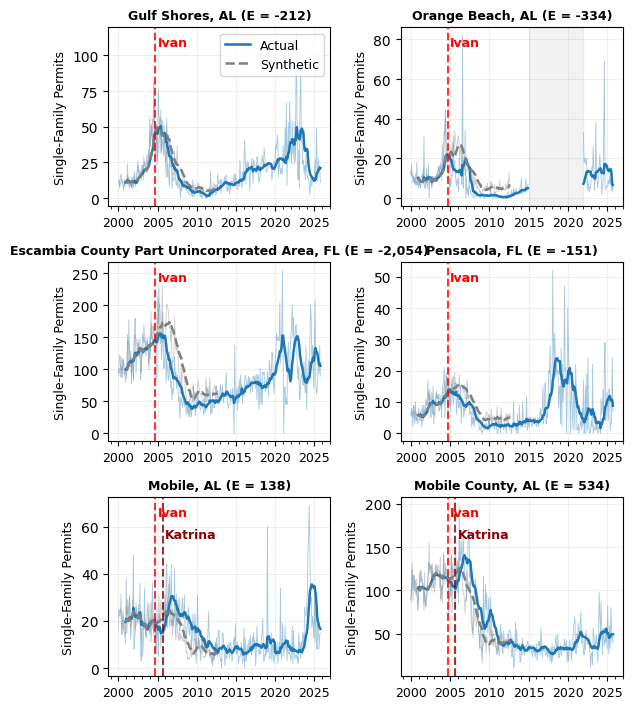

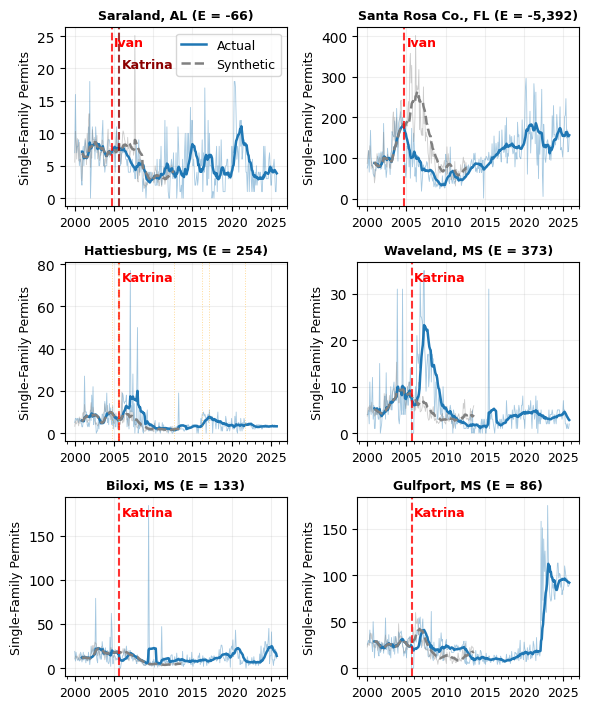

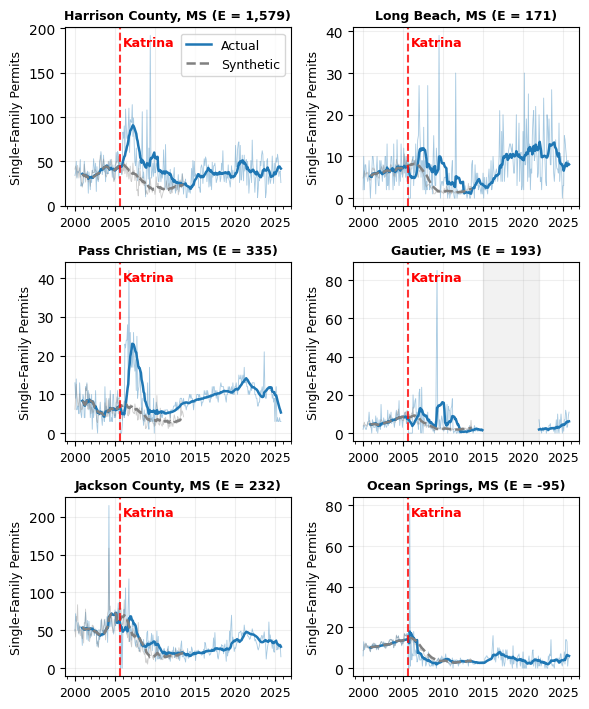

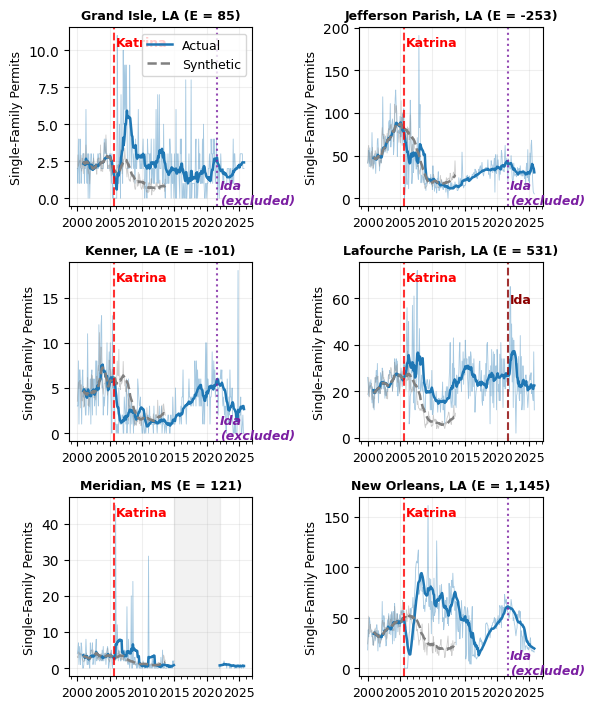

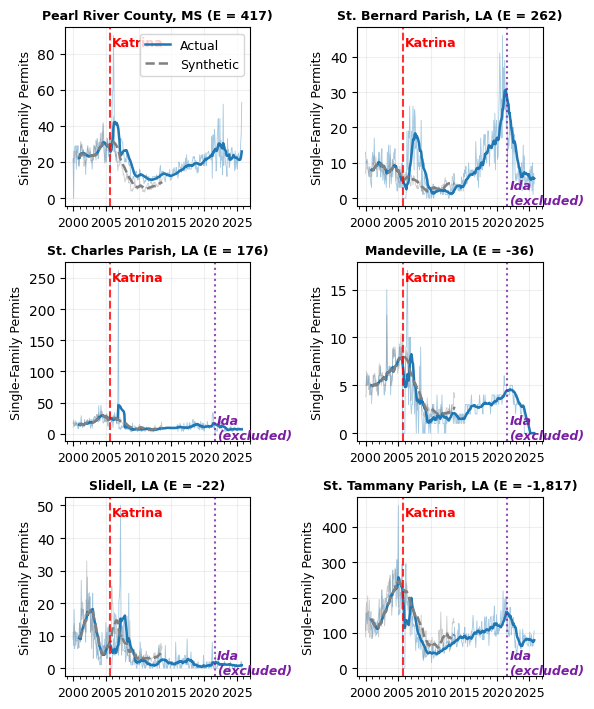

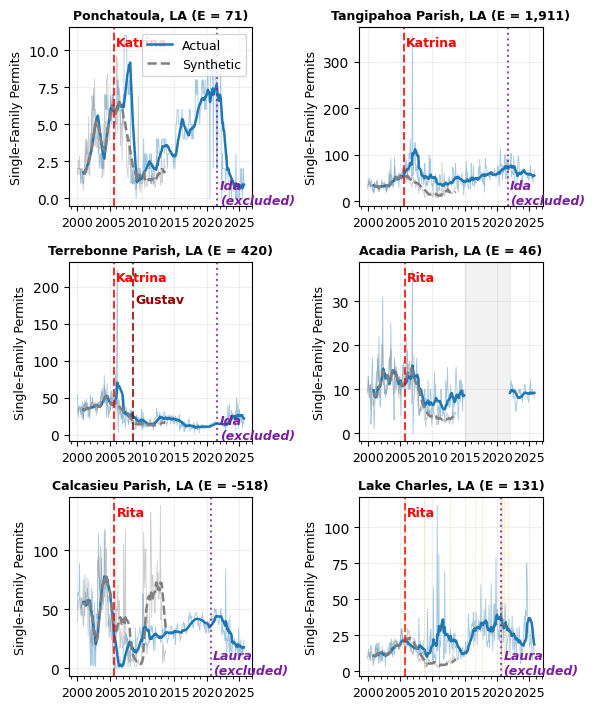

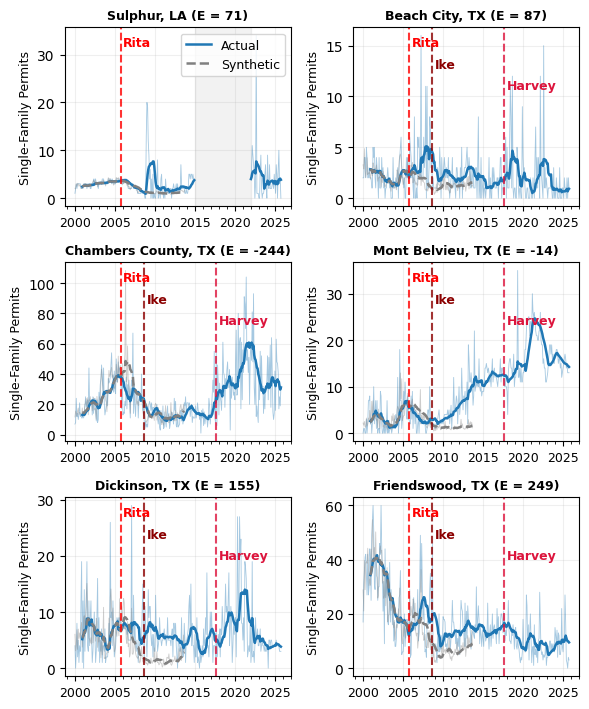

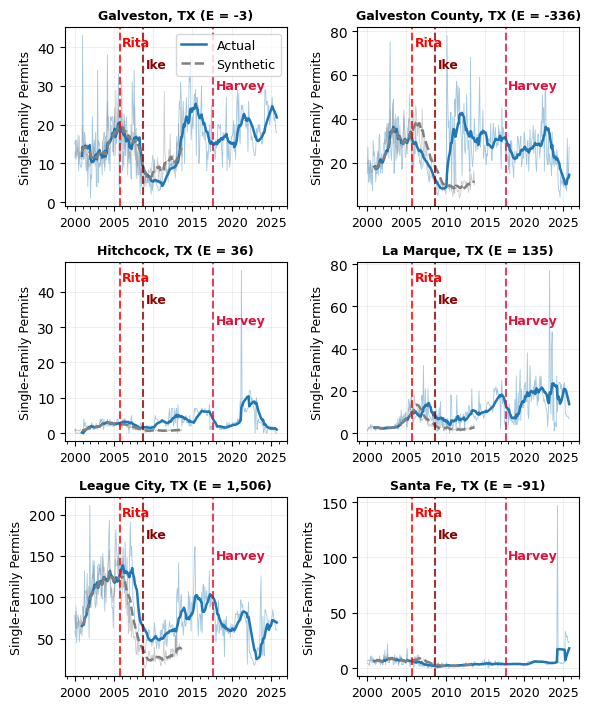

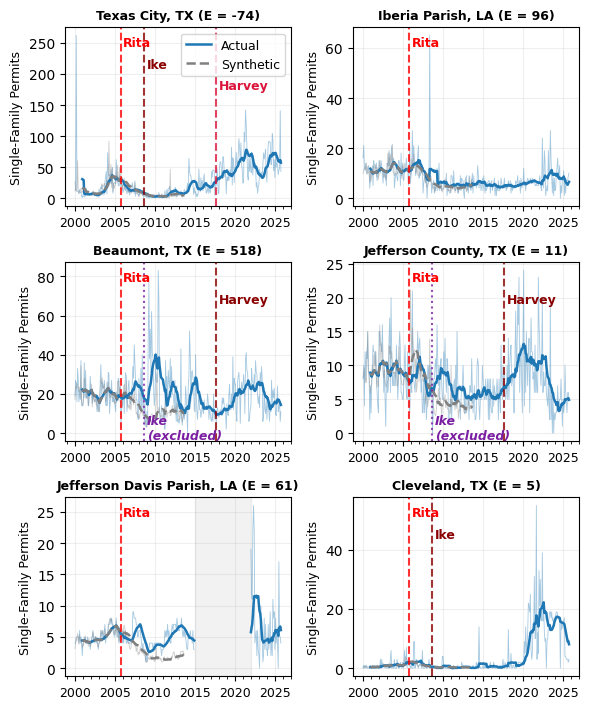

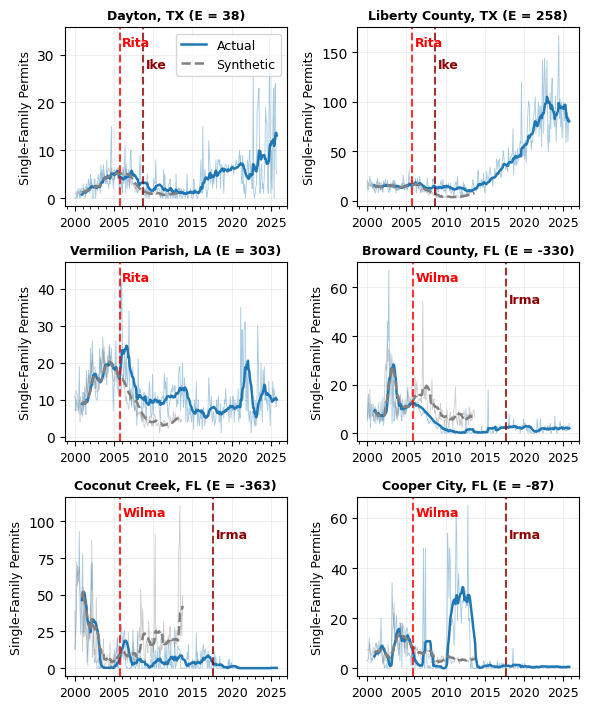

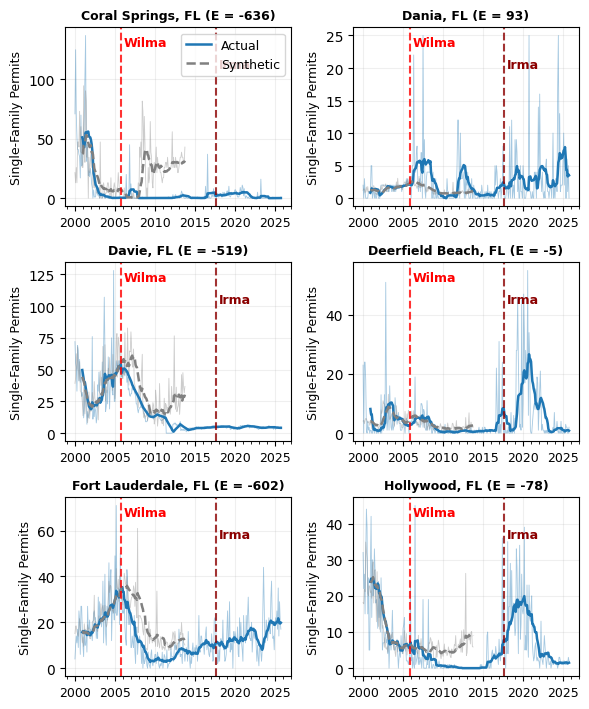

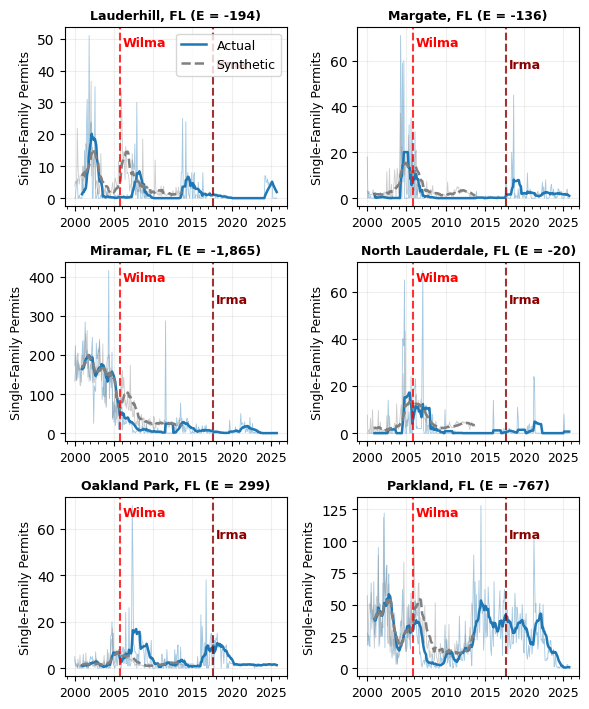

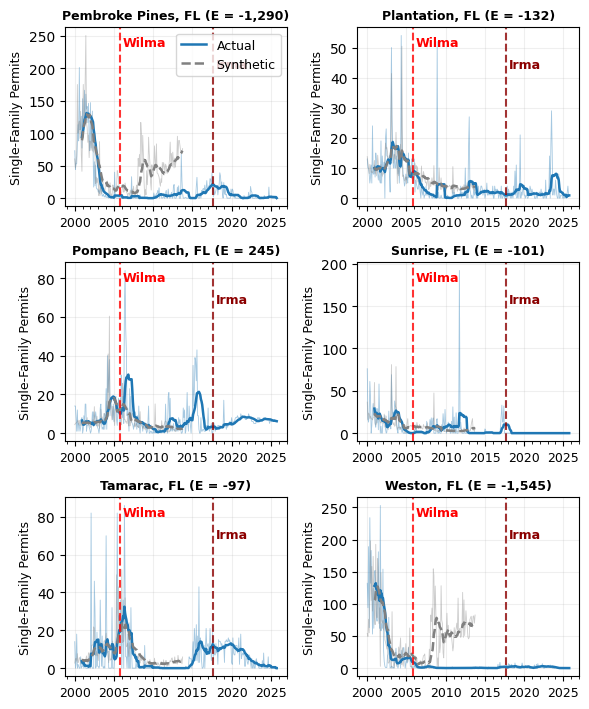

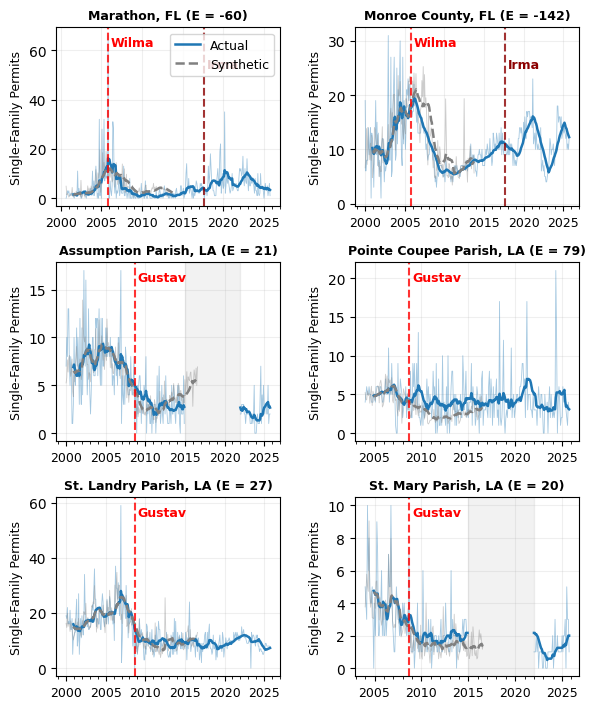

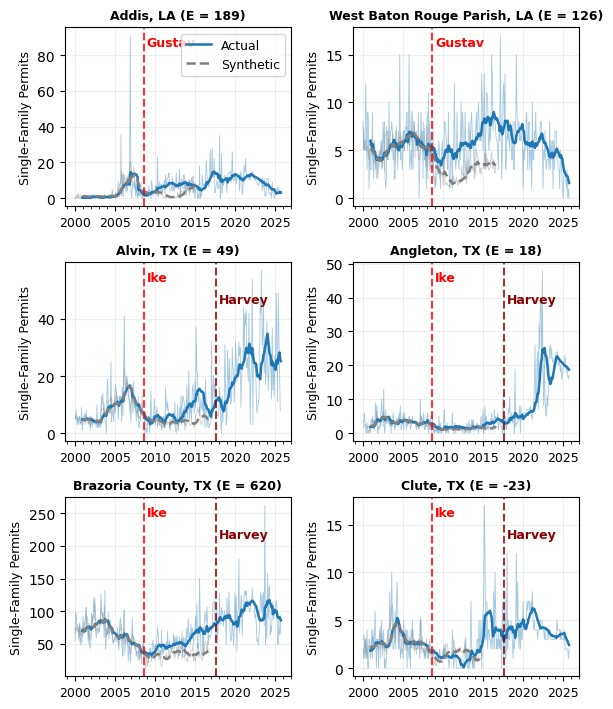

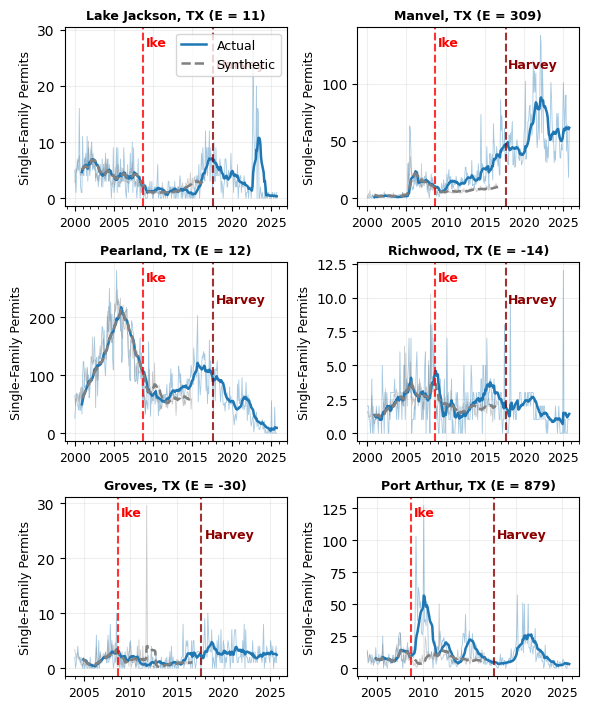

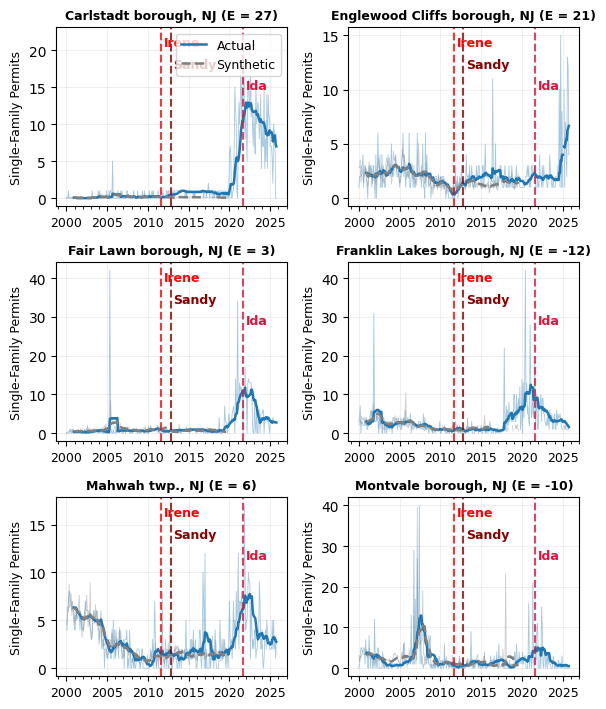

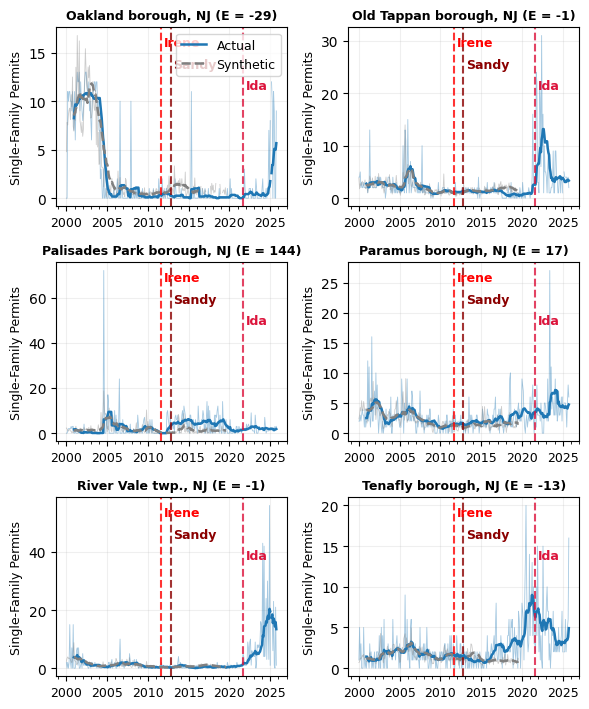

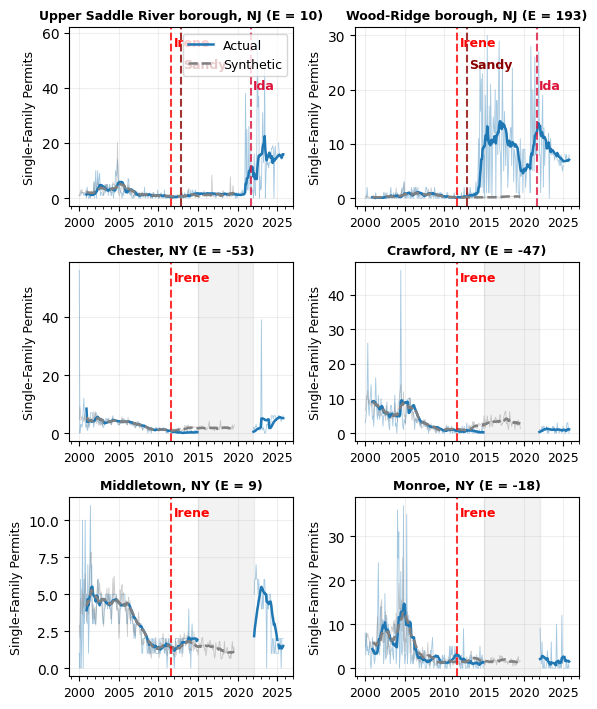

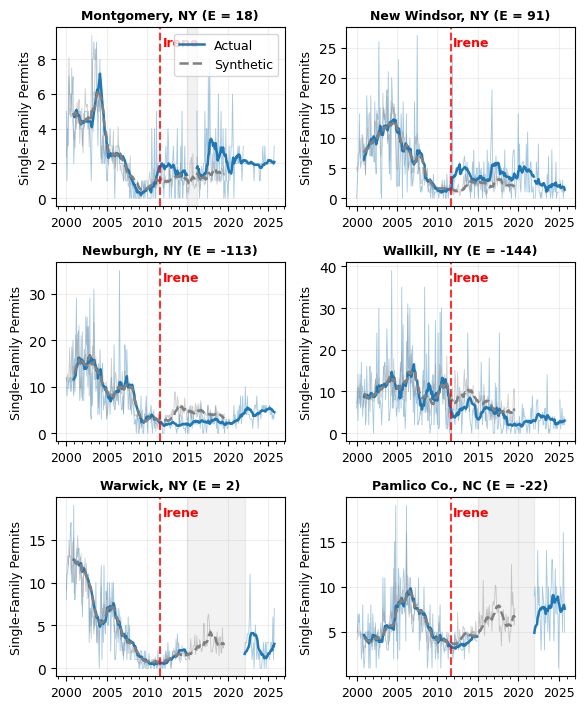

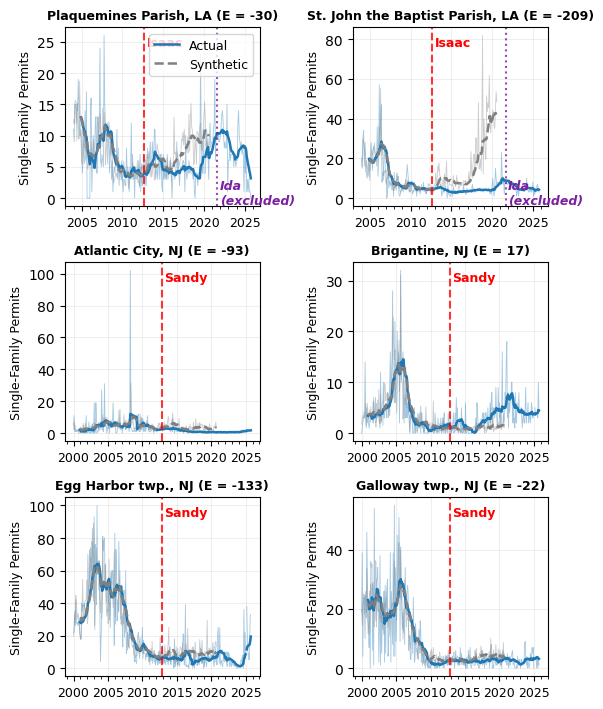

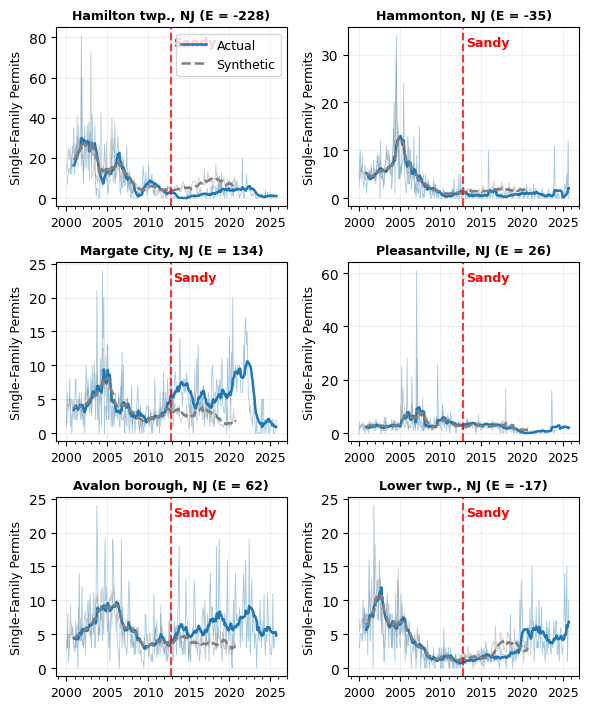

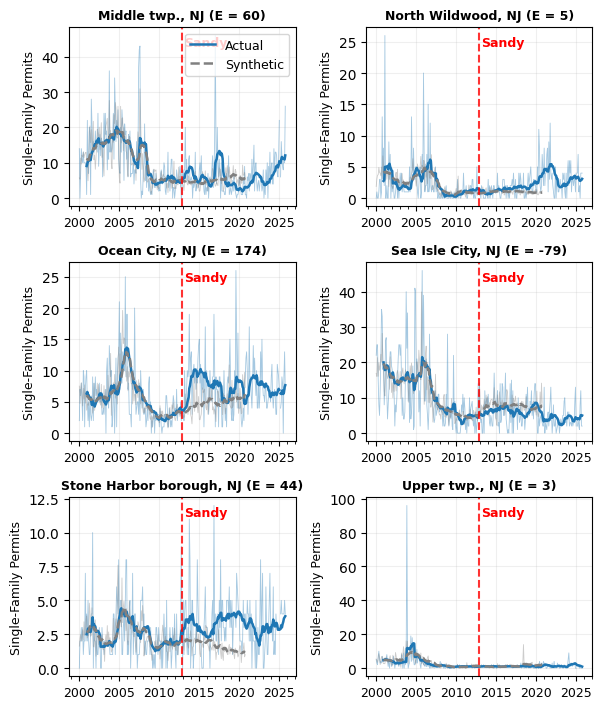

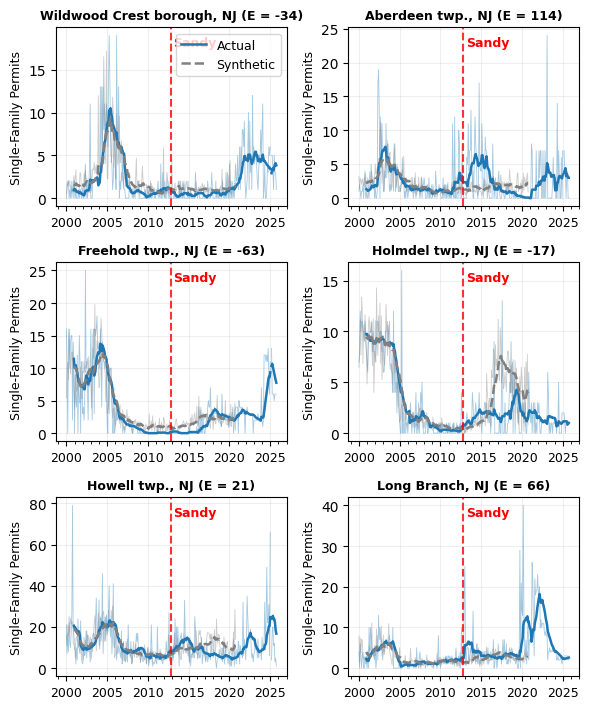

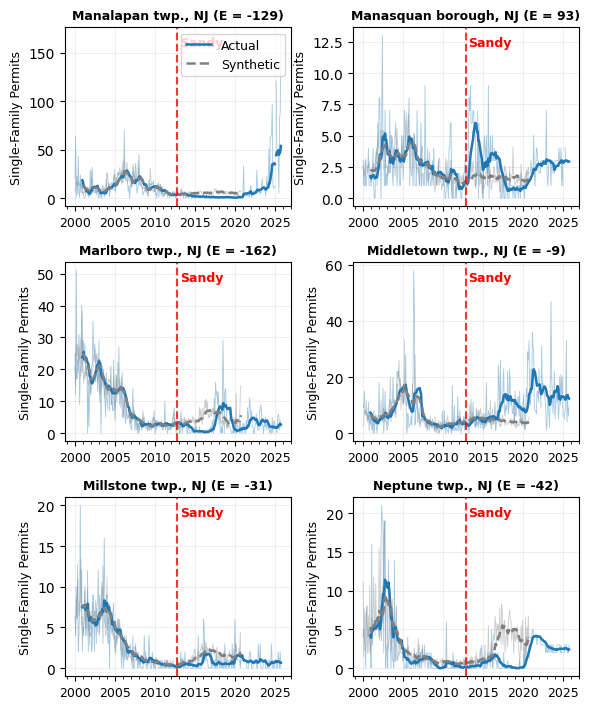

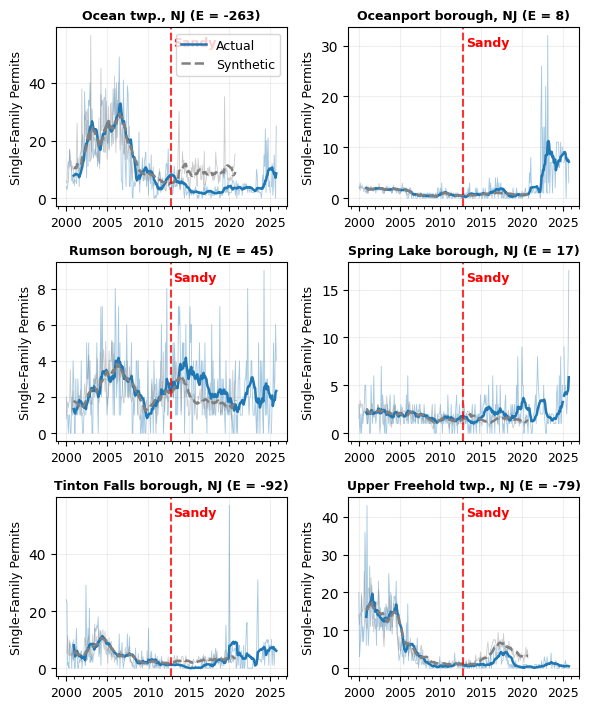

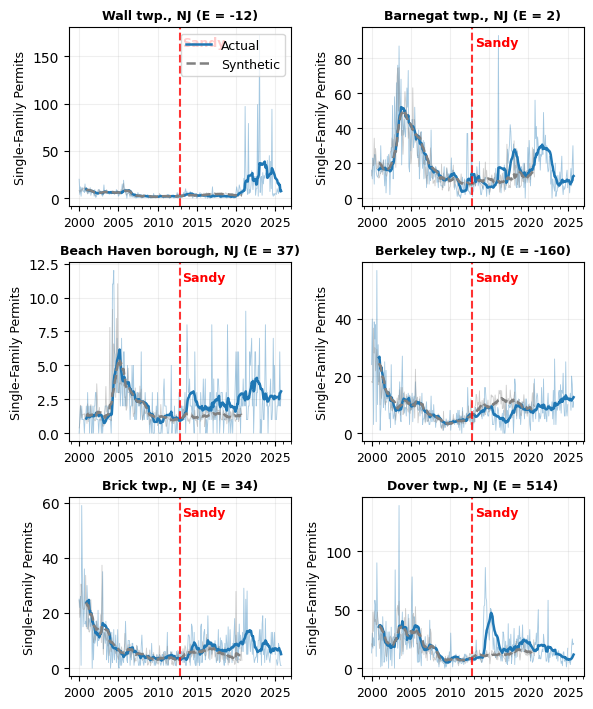

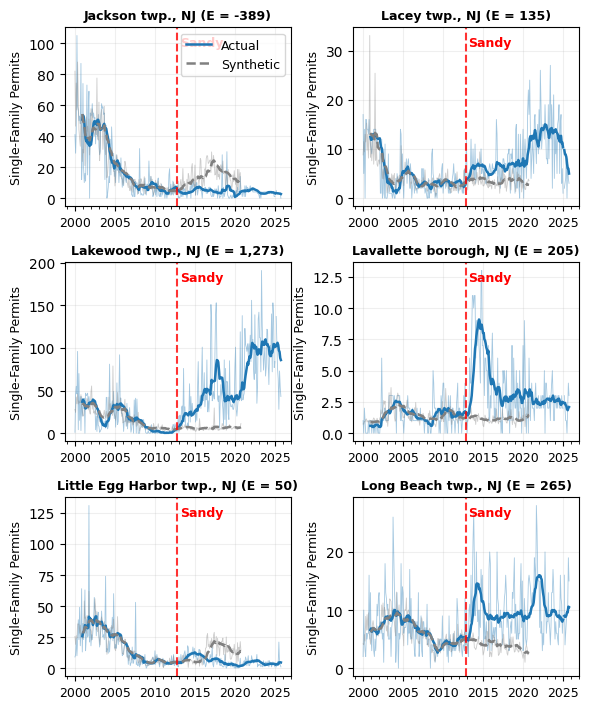

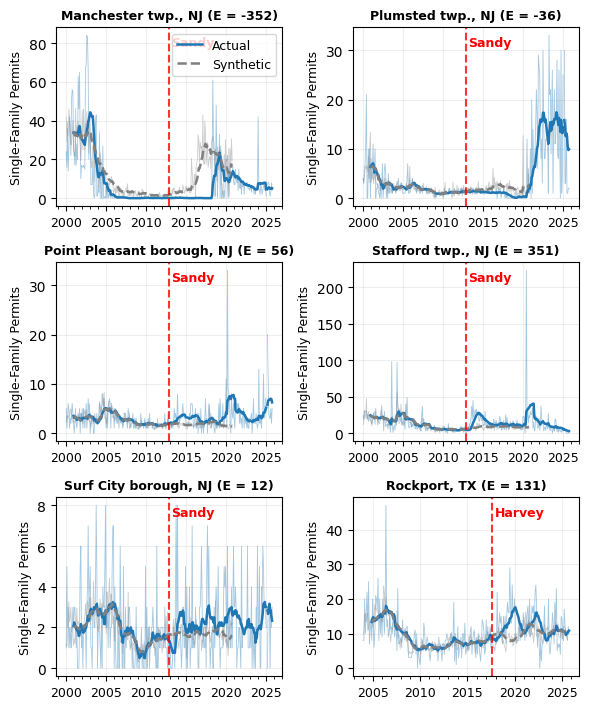

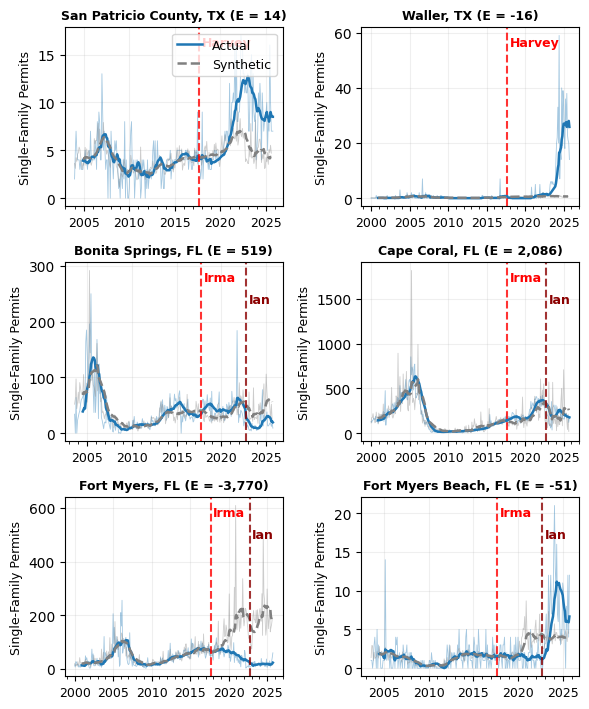

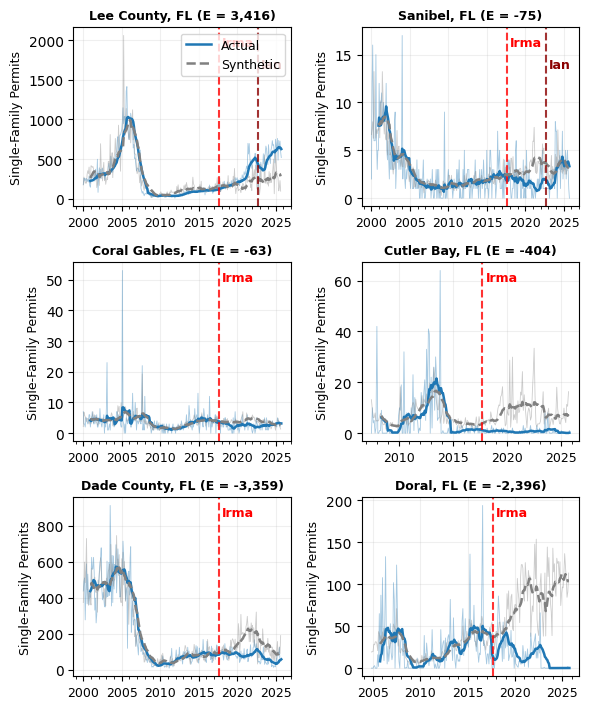

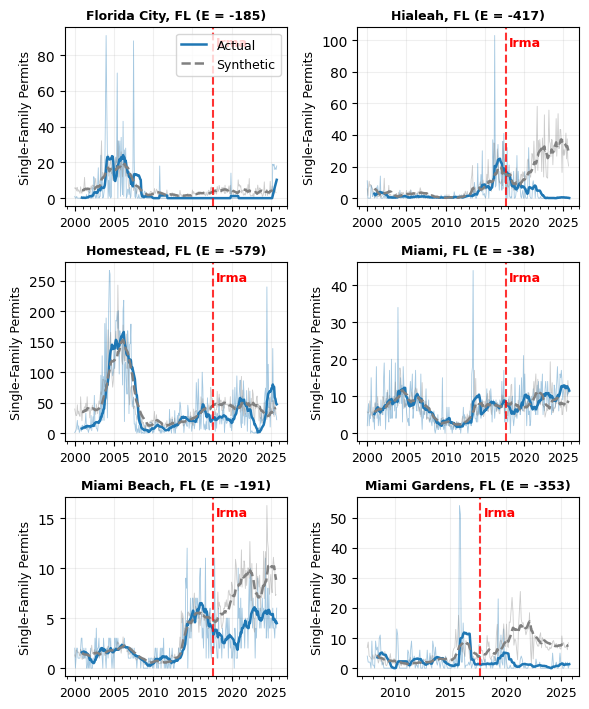

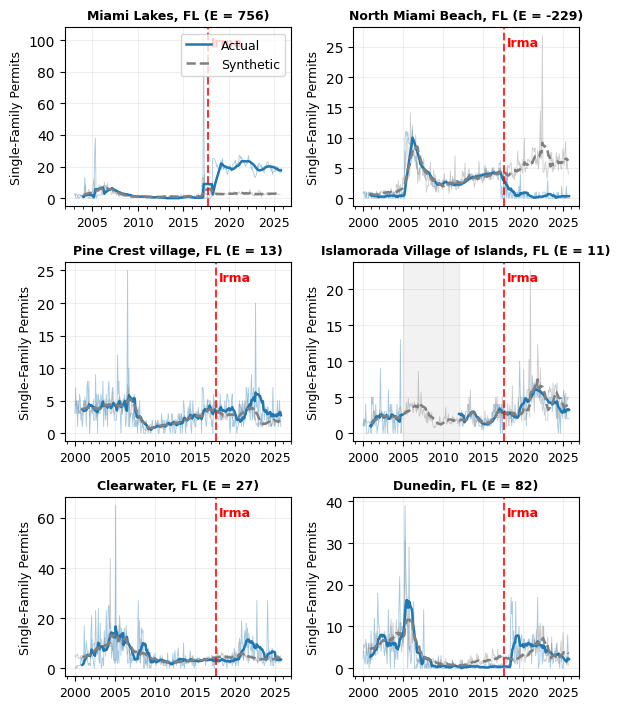

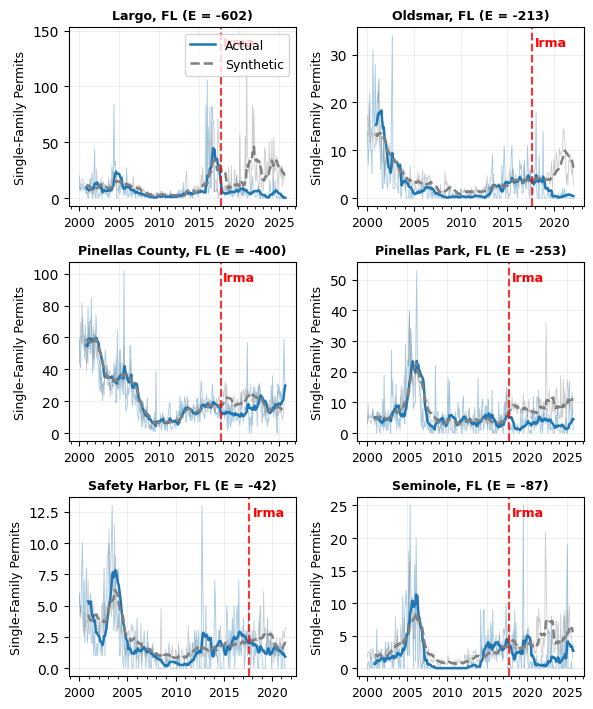

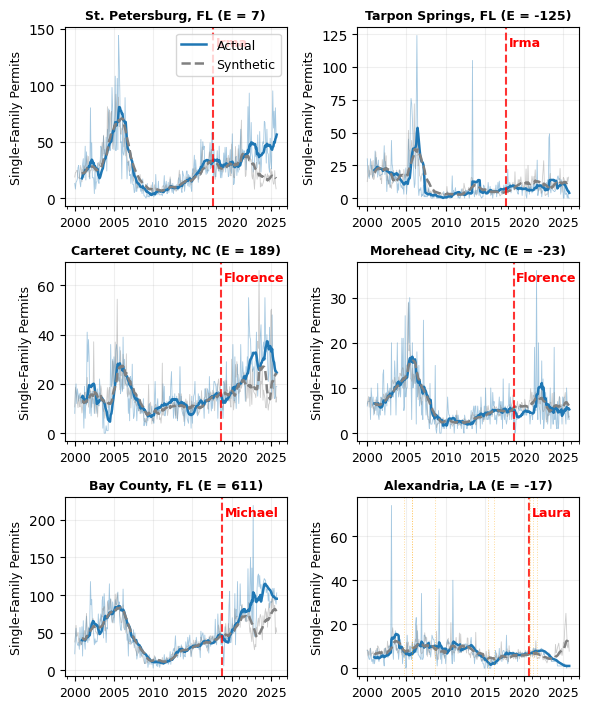

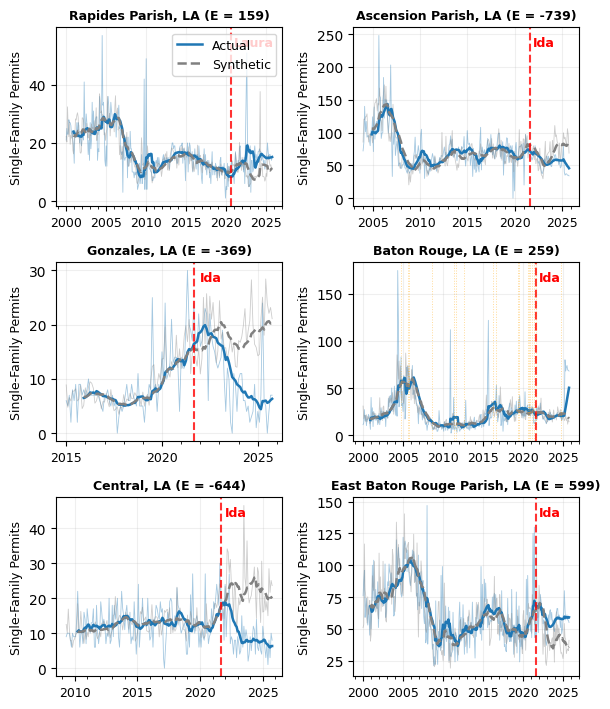

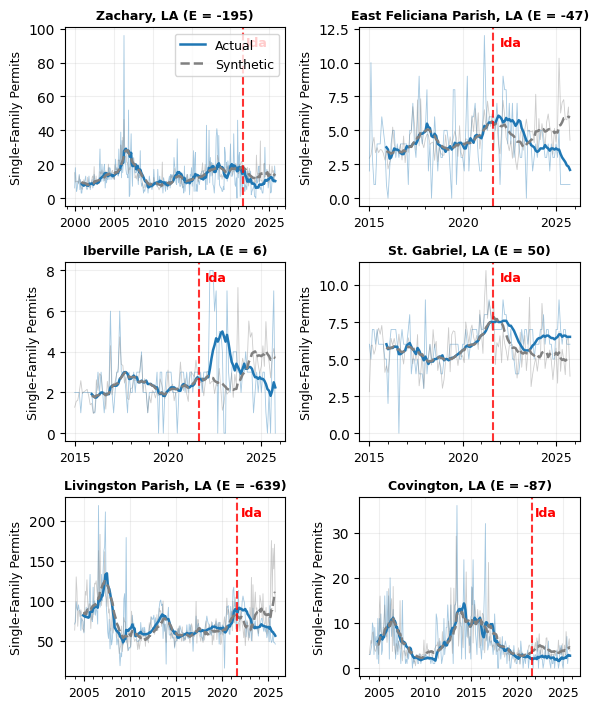

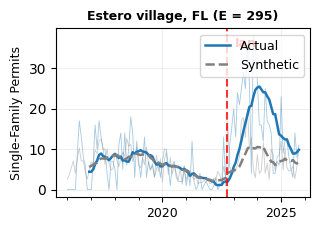

Hurricanes: 253 places, 380 events, 43 figures


In [52]:
items = list(hurr_events.items())
max_per_fig = 6
n_figs = max((len(items) + max_per_fig - 1) // max_per_fig, 1)

for fig_idx in range(n_figs):
    start = fig_idx * max_per_fig
    end = min(start + max_per_fig, len(items))
    chunk = dict(items[start:end])

    # Use safe numeric suffix instead of letters/symbols
    suffix = f"{fig_idx + 1:02d}"

    label = "Hurricanes: Actual vs Synthetic"
    if fig_idx > 0:
        label += " (continued)"

    save_path = FIGURES_DIR / f"fig_hurricane_events_place_{suffix}.pdf"

    plot_disaster_events(
        chunk,
        label,
        scm_results,
        ia_summary,
        disasters,
        save_path=save_path,
        excluded_events=EXCLUDED_EVENTS,
        excess_permits=excess_permits_dict
    )

n_events = sum(len(v) for v in hurr_events.values())
print(f"Hurricanes: {len(hurr_events)} places, {n_events} events, {n_figs} figures")

### Selected Examples (Paper Body)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17640\2120092027.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc=legend_loc)


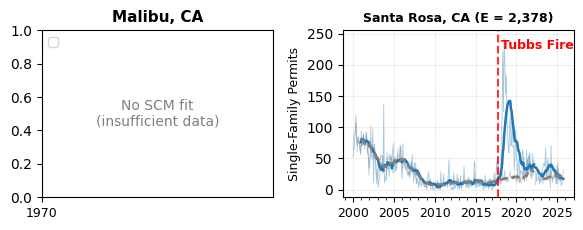

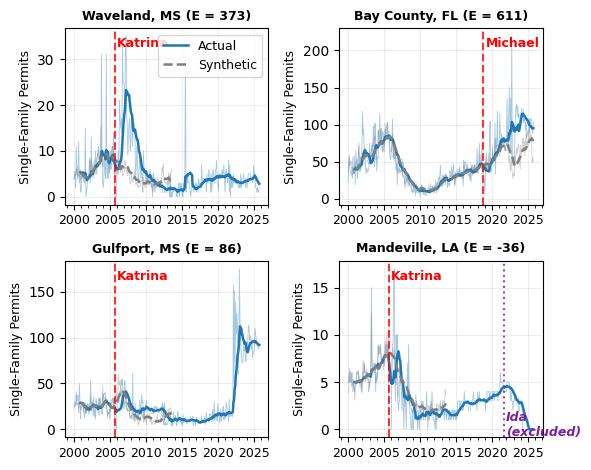

Selected examples: 2 fire, 4 hurricane


In [55]:
# --- Selected examples for paper body ---
# Wildfire: Malibu, Sonoma County
fire_selected = {k: v for k, v in fire_events.items()
                 if any(x in k for x in ['Malibu', 'Santa Rosa'])}
plot_disaster_events(fire_selected, 'Wildfires: Selected Examples',
                     scm_results, ia_summary, disasters,
                     save_path=FIGURES_DIR / 'fig_fire_selected.pdf', legend_loc='upper left',
                     excess_permits=excess_permits_dict)

# Hurricane: Waveland, Bay County, Gulfport, Mandeville (ordered for 2x2 layout)
hurr_order = ['Waveland', 'Bay Co.', 'Gulfport', 'Mandeville']
hurr_selected = {}
for name in hurr_order:
    for k, v in hurr_events.items():
        if name in k:
            hurr_selected[k] = v
plot_disaster_events(hurr_selected, 'Hurricanes: Selected Examples',
                     scm_results, ia_summary, disasters,
                     save_path=FIGURES_DIR / 'fig_hurricane_selected.pdf',
                     excluded_events=EXCLUDED_EVENTS,
                     excess_permits=excess_permits_dict)

print(f"Selected examples: {len(fire_selected)} fire, {len(hurr_selected)} hurricane")

### Excluded Places

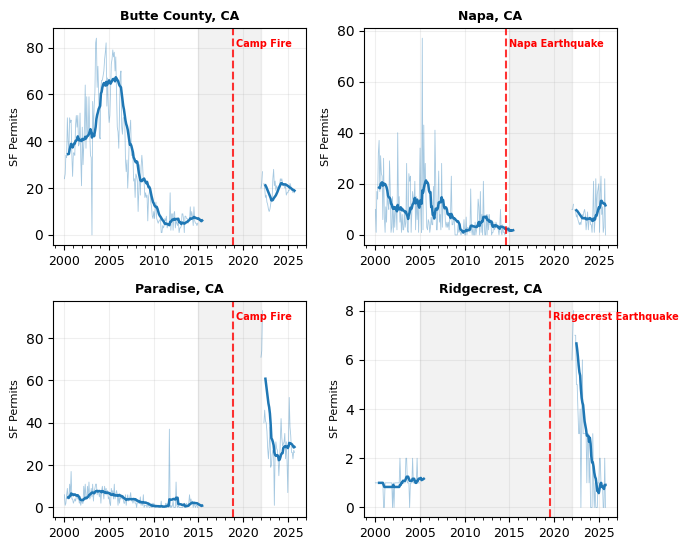

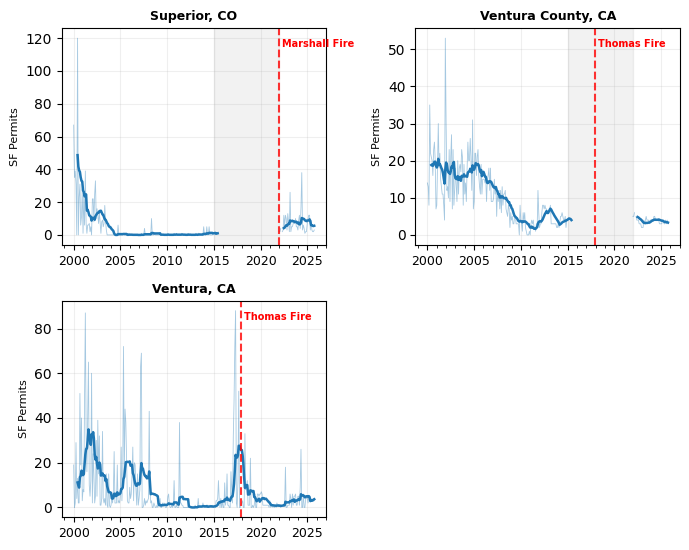

Excluded places plotted: ['Butte Co. (unincorp.), CA', 'Napa, CA', 'Paradise, CA', 'Ridgecrest, CA', 'Superior, CO', 'Ventura Co. (unincorp.), CA', 'Ventura, CA'], 2 figures


In [58]:
# --- Excluded places: raw time series (no SCM) ---
excl_names = sorted(EXCLUDED_PLACES)
excl_panel_data = {}
for pname in excl_names:
    pdata = panel[panel['metro_canonical'] == pname].sort_values('date')
    if len(pdata) == 0:
        continue
    excl_panel_data[pname] = pdata

# Rebuild events for excluded places from the original CSVs
excl_events = {}
for _, r in nonhurr_csv.iterrows():
    pname = r['pseudo_name']
    if pname in EXCLUDED_PLACES:
        excl_events.setdefault(pname, []).append(
            (r['date_csv'], r['disaster']))
for _, r in hurr_csv.drop_duplicates(['place_id', 'hurricane_name']).iterrows():
    pname = PLACE_PSEUDOS.get(r['place_id'])
    if pname and pname in EXCLUDED_PLACES:
        excl_events.setdefault(pname, []).append(
            (r['hurricane_date'], r['hurricane_name']))

excl_items = list(excl_panel_data.items())
max_per_fig = 4
n_figs = max((len(excl_items) + max_per_fig - 1) // max_per_fig, 1)

for fig_idx in range(n_figs):
    start = fig_idx * max_per_fig
    end = min(start + max_per_fig, len(excl_items))
    chunk = excl_items[start:end]
    n = len(chunk)
    ncols = 2
    nrows = max((n + ncols - 1) // ncols, 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7, 2.8 * nrows))
    if n == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)

    for i, (pname, pdata) in enumerate(chunk):
        ax = axes.flat[i]
        series = pdata.set_index('date')['units_1']
        series.index = pd.to_datetime(series.index)

        # Reindex to full monthly range so gaps become NaN (line breaks)
        full_idx = pd.date_range(series.index.min(), series.index.max(), freq='MS')
        series = series.reindex(full_idx)

        # Raw monthly
        ax.plot(series.index, series.values, linewidth=0.6, alpha=0.4, color='C0')

        # 12-month MA (NaNs propagate, creating line breaks at gaps)
        ma = series.rolling(12, min_periods=6).mean()
        ax.plot(ma.index, ma.values, linewidth=1.8, color='C0')

        # Gap shading
        gi = gap_info.get(pname)
        if gi:
            for g in gi:
                gs = pd.Timestamp(g['start'] + '-01')
                ge = pd.Timestamp(g['end'] + '-01') + pd.offsets.MonthEnd(1)
                ax.axvspan(gs, ge, alpha=0.10, color='gray', zorder=0)

        # Disaster event markers
        events = excl_events.get(pname, [])
        colors = ['red', 'darkred', 'crimson', 'firebrick']
        for j, (edate, ename) in enumerate(events):
            edt = pd.Timestamp(edate)
            c = colors[j % len(colors)]
            ax.axvline(edt, color=c, linewidth=1.5, linestyle='--', alpha=0.8)
            ymin, ymax = ax.get_ylim()
            ypos = ymax - (ymax - ymin) * (0.05 + 0.12 * j)
            ax.text(edt + pd.Timedelta(days=120), ypos,
                    ename, color=c, fontsize=7, va='top', fontweight='bold')

        ax.set_title(display_label(pname), fontweight='bold', fontsize=9)
        ax.set_ylabel('SF Permits', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator())
        ax.tick_params(axis='x', labelsize=9)

    for j in range(n, nrows * ncols):
        axes.flat[j].set_visible(False)

    suffix = chr(ord('a') + fig_idx)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'fig_excluded_places_{suffix}.pdf',
                bbox_inches='tight', dpi=150)
    plt.show()

print(f"Excluded places plotted: {list(excl_panel_data.keys())}, {n_figs} figures")


## Stacked Event Study

All events within each category are aligned on a common timeline (years
relative to disaster onset). Each trace shows the **ratio** of the actual
12-month MA to the synthetic 12-month MA, plotted on a logarithmic scale:

    ratio = actual_MA / synthetic_MA

A ratio of 1 means actual permits match the synthetic counterfactual.
Values above 1 indicate excess permitting. The log scale ensures that
equal multiplicative changes receive equal visual weight. The bold line
shows the **median** ratio across places.

In [61]:
def build_stacked_traces(metro_events_dict, scm_results):
    """Build event-study traces using actual/synthetic ratio."""
    traces = []
    for metro, events in metro_events_dict.items():
        res = scm_results.get(metro)
        if res is None:
            continue
        actual_ma = res['actual_ma']
        synth_ma = res['synthetic_ma']

        for edate, ename, dn in events:
            edt = pd.Timestamp(edate)
            win_start = edt - pd.DateOffset(years=4)
            win_end = edt + pd.DateOffset(years=4)

            # Reindex to complete monthly range so survey gaps become NaN
            full_range = pd.date_range(win_start, win_end, freq='MS')
            a = actual_ma.reindex(full_range)
            s = synth_ma.reindex(full_range)

            if a.notna().sum() < 12:
                continue

            # Actual/synthetic ratio (plotted on log scale)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = a / s
            ratio = ratio.replace([np.inf, -np.inf], np.nan)

            years_rel = (full_range - edt).days / 365.25
            trace_df = pd.DataFrame({
                'years_rel': years_rel,
                'ratio': ratio.values
            })
            # Keep NaN rows — they break plotted lines at survey gaps

            if trace_df['ratio'].notna().sum() >= 6:
                traces.append({'name': ename, 'metro': metro, 'dn': dn,
                               'data': trace_df})
    return traces


def plot_stacked_event_study(traces, category_label, ax):
    """Plot stacked event study with individual traces and median."""
    if len(traces) == 0:
        ax.text(0.5, 0.5, 'No traces', transform=ax.transAxes,
                ha='center', va='center', color='gray')
        ax.set_title(f'{category_label} (0 events)')
        return

    n_places = len(set(tr['metro'] for tr in traces))

    for i, tr in enumerate(traces):
        d = tr['data']
        ax.plot(d['years_rel'], d['ratio'],
                linewidth=0.8, alpha=0.3, color='C0',
                label='Individual place' if i == 0 else None)

    all_pts = pd.concat([tr['data'].assign(event=tr['name']) for tr in traces])
    all_pts['month_bin'] = (all_pts['years_rel'] * 12).round() / 12
    median_line = all_pts.groupby('month_bin')['ratio'].median()
    ax.plot(median_line.index, median_line.values,
            linewidth=2.5, color='black', label='Median')


    ax.axhline(1, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--', alpha=0.7,
               label='Disaster time')
    ax.set_yscale('log')
    ax.set_yticks([1/20, 1/10, 1/5, 1/2, 1, 2, 5, 10, 20])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(
        lambda v, _: f'{v:.0f}' if v >= 1 else f'1/{1/v:.0f}'))
    ax.set_xlabel('Years relative to disaster')
    ax.set_ylabel('Permit ratio (actual / synthetic)')
    ax.set_title(f'{category_label} ({n_places} places)')
    ax.set_xlim(-4, 4)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2, which='both')


fire_traces = build_stacked_traces(fire_events, scm_results)
hurr_traces = build_stacked_traces(hurr_events, scm_results)
tornado_traces = build_stacked_traces(tornado_events, scm_results)
earthquake_traces = build_stacked_traces(earthquake_events, scm_results)



## Placebo Tests

Following Abadie, Diamond, and Hainmueller (2010, 2015), we apply the
synthetic control method to non-disaster places as a placebo test.

The key inference statistic is the **post/pre RMSPE ratio**: the ratio
of post-treatment RMSPE to pre-treatment RMSPE. Disaster-affected places
should have substantially higher ratios than placebos if the disaster
caused a genuine departure from the counterfactual.

In [64]:
# --- Placebo Test: Apply SCM to non-disaster places ---
# Uses pickle cache to skip re-fitting when inputs haven't changed.
# Delete output/placebo_fits.pkl to force re-fitting.
import pickle

PLACEBO_CACHE = OUTPUT_DIR / 'placebo_fits.pkl'

if PLACEBO_CACHE.exists():
    with open(PLACEBO_CACHE, 'rb') as f:
        cache = pickle.load(f)
    placebo_results = cache['placebo_results']
    placebo_selections = cache['placebo_selections']
    state_disaster_dates = cache['state_disaster_dates']
    placebo_ratio_df = cache['placebo_ratio_df']
    treated_ratio_df = cache['treated_ratio_df']
    placebo_pids_passing = cache['placebo_pids_passing']
    print(f'Loaded placebo results from cache ({PLACEBO_CACHE.name})')
    print(f'  Delete {PLACEBO_CACHE} to force re-fitting')
    print(f'  Placebos: {len(placebo_ratio_df)}, Treated: {len(treated_ratio_df)}')
    print(f'\nPost/Pre RMSPE Ratios:')
    print(f'  Placebos (n={len(placebo_ratio_df)}): '
          f'median={placebo_ratio_df["ratio"].median():.2f}, '
          f'mean={placebo_ratio_df["ratio"].mean():.2f}')
    print(f'  Treated  (n={len(treated_ratio_df)}): '
          f'median={treated_ratio_df["ratio"].median():.2f}, '
          f'mean={treated_ratio_df["ratio"].mean():.2f}')
else:
    # Earliest disaster date per state
    state_disaster_dates = {}
    for pn, res in scm_results.items():
        if res is None:
            continue
        pid = name_to_pid.get(pn, '')
        st = pid[:2]
        pre_end = res['pre_end']
        if st not in state_disaster_dates or pre_end < state_disaster_dates[st]:
            state_disaster_dates[st] = pre_end

    print('Placebo treatment dates (earliest disaster per state):')
    for st in sorted(state_disaster_dates.keys()):
        print(f'  {STATE_NAMES.get(st, st)}: {state_disaster_dates[st].strftime("%Y-%m")}')

    # Select placebo places: non-disaster donors matched on permit volume
    N_PLACEBOS_PER_STATE = 10
    placebo_selections = {}

    for st in sorted(state_disaster_dates.keys()):
        treatment_date = state_disaster_dates[st]
        st_donors = donor_pool[donor_pool['state_fips'] == st]
        place_stats = st_donors.groupby('pid_str').agg(
            n_months=('date', 'nunique'),
            avg_permits=('units_1', 'mean'),
            min_date=('date', 'min'),
            max_date=('date', 'max'),
            place_name=('place_name', 'first')
        )

        # Require: enough data spanning treatment window
        post_needed = treatment_date + pd.DateOffset(months=48)
        pre_needed = treatment_date - pd.DateOffset(months=48)
        eligible = place_stats[
            (place_stats['avg_permits'] >= 2.0) &
            (place_stats['n_months'] >= 240) &
            (place_stats['min_date'] <= pre_needed) &
            (place_stats['max_date'] >= post_needed)
        ]

        # Match on permit volume (median of treated places in state)
        treated_in_state = [pn for pn in scm_results
                            if scm_results[pn] is not None
                            and name_to_pid.get(pn, '')[:2] == st]
        if treated_in_state:
            treated_avg = np.median([scm_results[pn]['actual'].mean()
                                     for pn in treated_in_state])
        else:
            treated_avg = 20.0

        eligible = eligible.copy()
        eligible['dist'] = (eligible['avg_permits'] - treated_avg).abs()
        eligible = eligible.sort_values('dist')
        selected = eligible.head(N_PLACEBOS_PER_STATE)

        placebo_selections[st] = [
            (pid, row['place_name'], row['avg_permits'])
            for pid, row in selected.iterrows()
        ]
        print(f'\n{STATE_NAMES.get(st, st)} \u2014 {len(eligible)} eligible, '
              f'selected {len(selected)} (treated median: {treated_avg:.1f}/mo):')
        for pid, row in selected.iterrows():
            print(f'  {row["place_name"]} ({pid}): {row["avg_permits"]:.1f}/mo')

    # Run SCM for all placebos
    placebo_results = {}
    for st, selections in placebo_selections.items():
        treatment_date = state_disaster_dates[st]
        for pid, pname, avg in selections:
            place_data = donor_pool[donor_pool['pid_str'] == pid].sort_values('date')
            series = place_data.set_index('date')['units_1']
            series.index = pd.to_datetime(series.index)

            res = build_scm_for_place(
                place_name=pname,
                pre_end_date=treatment_date,
                donor_pool=donor_pool,
                panel=panel,
                donor_mode='regional_excl_state',
                treated_pid=pid,
                treated_series=series)

            placebo_results[(st, pid)] = {
                'result': res,
                'place_name': pname,
                'treatment_date': treatment_date,
                'avg_permits': avg,
            }

    successful = sum(1 for v in placebo_results.values() if v['result'] is not None)
    print(f'\nPlacebo SCM: {successful}/{len(placebo_results)} successful fits')

    # --- Post/pre RMSPE ratios ---
    def compute_rmspe_ratio(act_ma, syn_ma, pre_end, post_months=48,
                            max_pre_months=999):
        # Compute post/pre RMSPE ratio for SCM inference.
        # Pre-period capped to last max_pre_months to avoid length bias.
        pre_act = act_ma[act_ma.index < pre_end].dropna()
        pre_syn = syn_ma.reindex(pre_act.index).dropna()
        common_pre = pre_act.index.intersection(pre_syn.index)
        if len(common_pre) > max_pre_months:
            common_pre = common_pre[-max_pre_months:]
        if len(common_pre) < 12:
            return np.nan, np.nan, np.nan, np.nan
        pre_vals = pre_act[common_pre].values
        syn_vals = pre_syn[common_pre].values
        pre_rmspe = np.sqrt(np.mean((pre_vals - syn_vals) ** 2))
        mean_pre = pre_vals.mean()
        rmspe_pct = pre_rmspe / mean_pre * 100 if mean_pre > 0 else np.nan

        post_end = pre_end + pd.DateOffset(months=post_months)
        post_act = act_ma[(act_ma.index >= pre_end) & (act_ma.index < post_end)].dropna()
        post_syn = syn_ma.reindex(post_act.index).dropna()
        common_post = post_act.index.intersection(post_syn.index)
        if len(common_post) < 12:
            return pre_rmspe, np.nan, np.nan, rmspe_pct
        post_rmspe = np.sqrt(np.mean(
            (post_act[common_post].values - post_syn[common_post].values) ** 2))
        ratio = post_rmspe / pre_rmspe if pre_rmspe > 0 else np.nan
        return pre_rmspe, post_rmspe, ratio, rmspe_pct

    # Placebo ratios
    placebo_ratios = []
    for key, info in placebo_results.items():
        res = info['result']
        if res is None:
            continue
        pre_rmspe, post_rmspe, ratio, rmspe_pct = compute_rmspe_ratio(
            res['actual_ma'].dropna(), res['synthetic_ma'], res['pre_end'])
        if np.isnan(ratio):
            continue
        act_pre = res['actual_ma'][res['actual_ma'].index < res['pre_end']].dropna()
        pre_months = len(act_pre)
        placebo_ratios.append({
            'state': key[0], 'pid': key[1],
            'place_name': info['place_name'],
            'pre_rmspe': pre_rmspe, 'post_rmspe': post_rmspe,
            'ratio': ratio, 'rmspe_pct': rmspe_pct,
            'pre_months': pre_months,
        })
    placebo_ratio_df = pd.DataFrame(placebo_ratios)

    # Treated ratios
    treated_ratios = []
    for pn, res in scm_results.items():
        if res is None:
            continue
        pre_rmspe, post_rmspe, ratio, rmspe_pct = compute_rmspe_ratio(
            res['actual_ma'].dropna(), res['synthetic_ma'], res['pre_end'])
        if np.isnan(ratio):
            continue
        act_pre = res['actual_ma'][res['actual_ma'].index < res['pre_end']].dropna()
        pre_months = len(act_pre)
        treated_ratios.append({
            'place_name': pn, 'pid': name_to_pid.get(pn, ''),
            'pre_rmspe': pre_rmspe, 'post_rmspe': post_rmspe, 'ratio': ratio,
            'rmspe_pct': rmspe_pct, 'pre_months': pre_months,
        })
    treated_ratio_df = pd.DataFrame(treated_ratios)

    # Filter placebos: drop those with pre-period RMSPE% > 2x treated median
    # (standard practice per Abadie et al. 2010, 2015)
    # RMSPE% computed on capped 120-month pre-window to avoid length bias
    treated_median_rmspe = treated_ratio_df['rmspe_pct'].median()
    rmspe_threshold = 999 * treated_median_rmspe
    n_before = len(placebo_ratio_df)
    placebo_ratio_df = placebo_ratio_df[placebo_ratio_df['rmspe_pct'] <= rmspe_threshold].copy()
    print(f'\nPlacebo RMSPE% filter: {n_before - len(placebo_ratio_df)}/{n_before} dropped '
          f'(threshold: {rmspe_threshold:.1f}% = 2x treated median {treated_median_rmspe:.1f}%)')

    # Track which placebos passed the filter (for stacked traces)
    placebo_pids_passing = set(placebo_ratio_df['pid'].values)

    print(f'\nPost/Pre RMSPE Ratios:')
    print(f'  Placebos (n={len(placebo_ratio_df)}): '
          f'median={placebo_ratio_df["ratio"].median():.2f}, '
          f'mean={placebo_ratio_df["ratio"].mean():.2f}')
    print(f'  Treated  (n={len(treated_ratio_df)}): '
          f'median={treated_ratio_df["ratio"].median():.2f}, '
          f'mean={treated_ratio_df["ratio"].mean():.2f}')

    # Save cache
    with open(PLACEBO_CACHE, 'wb') as f:
        pickle.dump({
            'placebo_results': placebo_results,
            'placebo_selections': placebo_selections,
            'state_disaster_dates': state_disaster_dates,
            'placebo_ratio_df': placebo_ratio_df,
            'treated_ratio_df': treated_ratio_df,
            'placebo_pids_passing': placebo_pids_passing,
        }, f)
    print(f'\nSaved placebo results to {PLACEBO_CACHE.name}')

Placebo treatment dates (earliest disaster per state):
  AL: 2004-09
  CA: 2017-10
  FL: 2004-08
  HI: 2023-08
  LA: 2005-08
  MS: 2005-08
  MO: 2011-05
  NJ: 2011-08
  NY: 2011-08
  NC: 2011-08
  OK: 2013-05
  TX: 2005-09

AL — 43 eligible, selected 10 (treated median: 19.8/mo):
  Gulf Shores (1224000.0): 19.8/mo
  Calera (1072000.0): 19.7/mo
  Daphne (1130000.0): 19.4/mo
  Opelika (1378000.0): 19.1/mo
  Dothan (1141000.0): 21.5/mo
  Prattville (1409000.0): 17.7/mo
  Trussville (1494000.0): 16.8/mo
  Athens (1025000.0): 16.7/mo
  Fairhope (1168000.0): 23.4/mo
  Pelham (1388000.0): 15.0/mo

CA — 239 eligible, selected 10 (treated median: 30.8/mo):
  Santa Clarita (6414000.0): 30.9/mo
  Hesperia (6178000.0): 31.2/mo
  Fairfield (6137000.0): 30.2/mo
  Perris (6328000.0): 31.7/mo
  Madera County Unincorporated Area (6251000.0): 32.1/mo
  Chino (6072000.0): 28.6/mo
  Rancho Cucamonga (6349000.0): 33.2/mo
  Ontario (6307000.0): 28.4/mo
  Dublin (6120000.0): 28.2/mo
  Riverside (6365000.0): 

Plotting 6 placebo examples


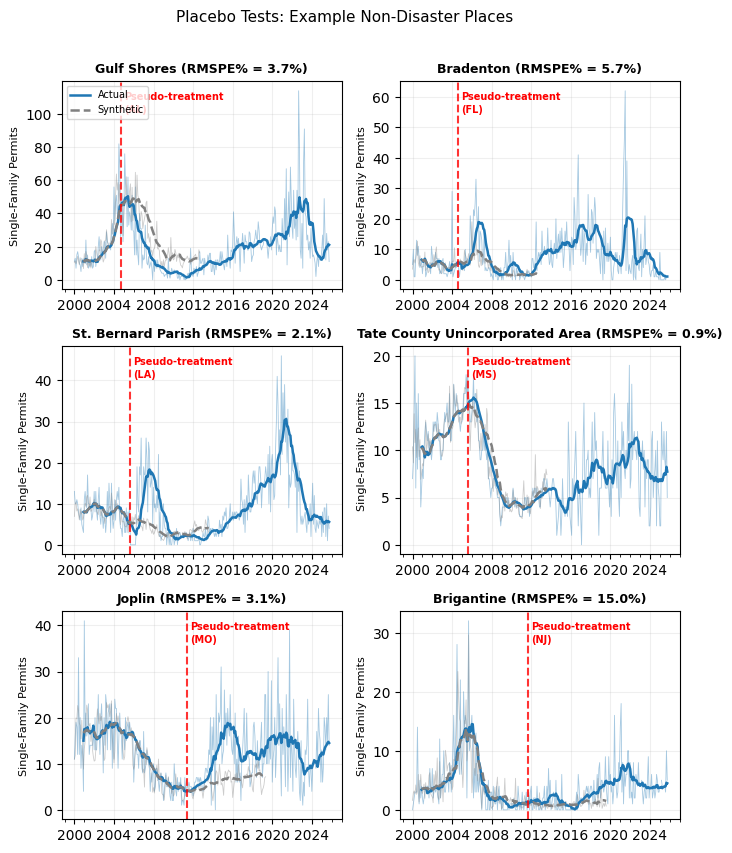

In [65]:
# --- Example placebo time series: matching disaster event plot style ---
placebo_examples = {}
for key, info in placebo_results.items():
    st = key[0]
    res = info['result']
    if res is None:
        continue
    if st not in placebo_examples:
        placebo_examples[st] = (key, info)

example_keys = [placebo_examples[st] for st in sorted(placebo_examples.keys())][:6]
n = len(example_keys)
print(f'Plotting {n} placebo examples')

ncols = 2
nrows = max((n + ncols - 1) // ncols, 1)
fig, axes = plt.subplots(nrows, ncols, figsize=(7, 2.8 * nrows))
if nrows == 1 and ncols > 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flat

for i, (key, info) in enumerate(example_keys):
    ax = axes_flat[i]
    res = info['result']
    pre_end = res['pre_end']

    # Reindex actual to full monthly range (gaps become NaN -> line breaks)
    full_idx = pd.date_range(res['actual'].index.min(),
                             res['actual'].index.max(), freq='MS')
    actual = res['actual'].reindex(full_idx)
    actual_ma = res['actual_ma'].reindex(full_idx)
    synthetic = res['synthetic']
    synthetic_ma = res['synthetic_ma']

    # Truncate synthetic display at treatment + 8 years
    synth_end = pre_end + pd.DateOffset(years=8)
    synth_mask = synthetic.index <= synth_end
    synth_ma_mask = synthetic_ma.index <= synth_end

    # Raw monthly
    ax.plot(actual.index, actual.values,
            linewidth=0.6, alpha=0.4, color='C0')
    ax.plot(synthetic.index[synth_mask],
            synthetic.values[synth_mask],
            linewidth=0.6, alpha=0.4, color='gray')

    # 12-month MA
    ax.plot(actual_ma.index, actual_ma.values,
            linewidth=1.8, color='C0', label='Actual')
    ax.plot(synthetic_ma.index[synth_ma_mask],
            synthetic_ma.values[synth_ma_mask],
            linewidth=1.8, color='gray', linestyle='--', label='Synthetic')

    # Treatment date marker
    ax.axvline(pre_end, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
    st_name = STATE_NAMES.get(key[0], key[0])
    ymin, ymax = ax.get_ylim()
    ax.text(pre_end + pd.Timedelta(days=120), ymax - (ymax - ymin) * 0.05,
            f'Pseudo-treatment\n({st_name})',
            color='red', fontsize=7, va='top', fontweight='bold', linespacing=1.3)

    rmspe = res['rmspe_pct']
    ax.set_title(f'{info["place_name"]} (RMSPE% = {rmspe:.1f}%)',
                fontweight='bold', fontsize=9)
    ax.set_ylabel('Single-Family Permits', fontsize=8)
    ax.grid(True, alpha=0.2)

# Legend on first axis
axes_flat[0].legend(fontsize=7, loc='upper left')

for j in range(n, nrows * ncols):
    axes_flat[j].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.xaxis.set_major_locator(mdates.YearLocator(4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator())

fig.suptitle('Placebo Tests: Example Non-Disaster Places', y=1.01, fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_placebo_examples.pdf', bbox_inches='tight', dpi=150)
plt.show()


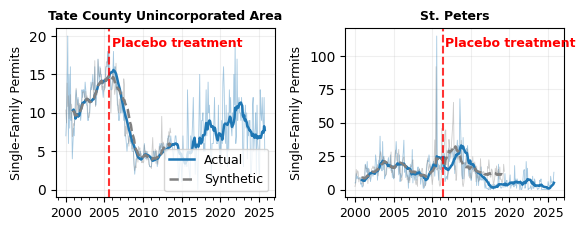

Placebo selected examples: ['Tate County Unincorporated Area', 'St. Peters']


In [66]:
# --- Placebo selected examples for paper body ---
placebo_selected_events = {}
placebo_selected_scm = {}
for (st, pid), info in placebo_results.items():
    if info['result'] is None:
        continue
    pname = info['place_name']
    if 'Tate County' in pname or 'St. Peters' in pname:
        placebo_selected_events[pname] = [
            (info['treatment_date'].strftime('%Y-%m-%d'), 'Placebo treatment', None)]
        placebo_selected_scm[pname] = info['result']
plot_disaster_events(placebo_selected_events, 'Placebos: Selected Examples',
                     placebo_selected_scm, ia_summary, disasters,legend_loc='lower right',
                     save_path=FIGURES_DIR / 'fig_placebo_selected.pdf')
print(f"Placebo selected examples: {list(placebo_selected_events.keys())}")

Placebo traces: 98


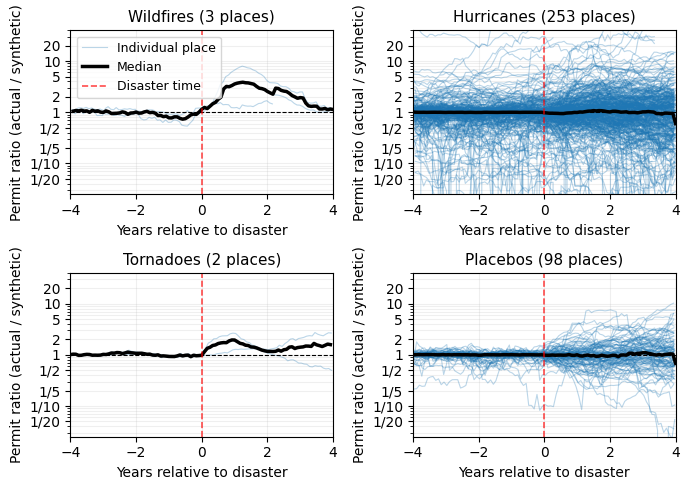

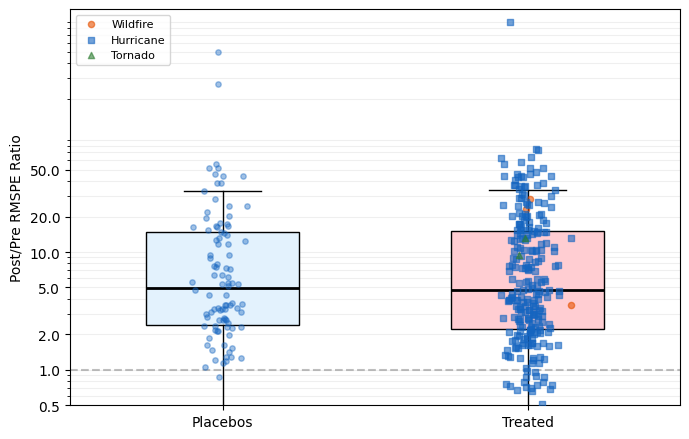


Median treated ratio: 4.75
Placebos with ratio >= median treated: 50/98 (51.0%)

Saved 356 rows to rmspe_ratios.csv
           count   mean    std   min    25%    50%    75%     max
type                                                             
Hurricane  253.0  14.86  57.03  0.13   2.18   4.67  14.92  889.25
Placebo     98.0  17.99  57.02  0.31   2.40   4.93  14.79  501.00
Tornado      2.0  11.28   2.58  9.45  10.36  11.28  12.19   13.10
Wildfire     3.0  18.30  13.03  3.57  13.29  23.02  25.66   28.31


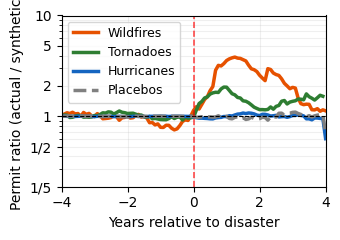


Median post/pre RMSPE ratio:
  Placebos: 4.93
  Treated:  4.75
Treated with ratio < placebo median: 131/258 (50.8%)


In [67]:
# Build placebo traces for stacked event study (filtered by RMSPE%)
placebo_scm_temp = {}
placebo_events_temp = {}
for (st, pid), info in placebo_results.items():
    if info['result'] is None:
        continue
    if pid not in placebo_pids_passing:
        continue
    key = f'placebo_{pid}'
    placebo_scm_temp[key] = info['result']
    treatment = state_disaster_dates[st]
    placebo_events_temp[key] = [(treatment.strftime('%Y-%m-%d'), 'Placebo', None)]

placebo_traces = build_stacked_traces(placebo_events_temp, placebo_scm_temp)
print(f'Placebo traces: {len(placebo_traces)}')

# --- Updated 2x2: Wildfires, Hurricanes, Tornadoes, Placebos ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 5))
plot_stacked_event_study(fire_traces, 'Wildfires', ax1)
plot_stacked_event_study(hurr_traces, 'Hurricanes', ax2)
plot_stacked_event_study(tornado_traces, 'Tornadoes', ax3)
plot_stacked_event_study(placebo_traces, 'Placebos', ax4)

# Remove legend from all but upper-left panel
for ax in [ax2, ax3, ax4]:
    legend = ax.get_legend()
    if legend:
        legend.remove()

# Sync y-axes: fixed range 1/40 to 40
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_ylim(1/40, 40)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_stacked_events_place.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

# --- Post/Pre RMSPE Ratio Comparison ---
fig, ax = plt.subplots(figsize=(7, 4.5))
data_bp = [placebo_ratio_df['ratio'].dropna().values,
           treated_ratio_df['ratio'].dropna().values]
bp = ax.boxplot(data_bp, tick_labels=['Placebos', 'Treated'],
                widths=0.5, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('#e3f2fd')
bp['boxes'][1].set_facecolor('#ffcdd2')

# Placebos: single color
x_plac = np.random.normal(1, 0.04, size=len(data_bp[0]))
ax.scatter(x_plac, data_bp[0], alpha=0.4, s=15, color='#1565c0', zorder=3)

# Treated: color-code by hazard type
hazard_colors = {'Wildfire': '#e65100', 'Hurricane': '#1565c0',
                 'Tornado': '#2e7d32', 'Earthquake': '#6a1b9a'}
hazard_markers = {'Wildfire': 'o', 'Hurricane': 's',
                  'Tornado': '^', 'Earthquake': 'D'}
treated_cats = []
for pn in treated_ratio_df['place_name']:
    if pn in fire_events:
        treated_cats.append('Wildfire')
    elif pn in hurr_events:
        treated_cats.append('Hurricane')
    elif pn in tornado_events:
        treated_cats.append('Tornado')
    elif pn in earthquake_events:
        treated_cats.append('Earthquake')
    else:
        treated_cats.append('Unknown')
treated_ratio_df['hazard'] = treated_cats
for hazard, color in hazard_colors.items():
    mask = treated_ratio_df['hazard'] == hazard
    if mask.sum() == 0:
        continue
    vals = treated_ratio_df.loc[mask, 'ratio'].values
    x_t = np.random.normal(2, 0.04, size=len(vals))
    ax.scatter(x_t, vals, alpha=0.6, s=20,
              color=color, marker=hazard_markers[hazard],
              label=f'{hazard}', zorder=3)
ax.legend(loc='upper left', framealpha=0.8)

ax.set_yscale('log')
ymax_data = max(d.max() for d in data_bp)
ax.set_ylim(0.5, ymax_data * 1.3)
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylabel('Post/Pre RMSPE Ratio')
# ax.set_title('Post/Pre RMSPE Ratios: Treated vs Placebo Places')
ax.axhline(1, color='gray', ls='--', alpha=0.5)
ax.grid(True, alpha=0.2, which='both', axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_rmspe_ratio_comparison.pdf', bbox_inches='tight')
plt.show()

# Significance: fraction of placebos with ratio >= median treated
median_treated_ratio = treated_ratio_df['ratio'].median()
n_exceed = (placebo_ratio_df['ratio'] >= median_treated_ratio).sum()
print(f'\nMedian treated ratio: {median_treated_ratio:.2f}')
print(f'Placebos with ratio >= median treated: {n_exceed}/{len(placebo_ratio_df)} '
      f'({n_exceed/len(placebo_ratio_df)*100:.1f}%)')


# --- Export RMSPE ratio table ---
placebo_export = placebo_ratio_df[['pid', 'place_name', 'ratio']].copy()
placebo_export['type'] = 'Placebo'

treated_export = treated_ratio_df[['pid', 'place_name', 'ratio', 'hazard']].copy()
treated_export = treated_export.rename(columns={'hazard': 'type'})

rmspe_ratio_table = pd.concat([placebo_export, treated_export], ignore_index=True)
rmspe_ratio_table = rmspe_ratio_table.rename(columns={'pid': 'id_number', 'place_name': 'name', 'ratio': 'rmspe_ratio'})
rmspe_ratio_table = rmspe_ratio_table[['id_number', 'name', 'type', 'rmspe_ratio']]
rmspe_ratio_table.to_csv(OUTPUT_DIR / 'rmspe_ratios.csv', index=False)
print(f'\nSaved {len(rmspe_ratio_table)} rows to rmspe_ratios.csv')
print(rmspe_ratio_table.groupby('type')['rmspe_ratio'].describe().round(2))

# --- Stacked median ratio comparison (all categories on one plot) ---
def compute_median_trace(traces):
    if not traces:
        return pd.Series(dtype=float)
    all_pts = pd.concat([tr['data'] for tr in traces])
    all_pts['month_bin'] = (all_pts['years_rel'] * 12).round() / 12
    return all_pts.groupby('month_bin')['ratio'].median()

fig, ax = plt.subplots(figsize=(3.5, 2.5))
trace_sets = [
    (fire_traces, 'Wildfires', '#e65100'),
    (tornado_traces, 'Tornadoes', '#2e7d32'),
    (hurr_traces, 'Hurricanes', '#1565c0'),
    (placebo_traces, 'Placebos', '0.5'),
]
for traces, label, color in trace_sets:
    med = compute_median_trace(traces)
    ls = '--' if label == 'Placebos' else '-'
    ax.plot(med.index, med.values, linewidth=2.5, color=color,
            linestyle=ls, label=label)

ax.axhline(1, color='k', linewidth=0.8, linestyle='--')
ax.axvline(0, color='red', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_yscale('log')
ax.set_yticks([1/5, 1/2, 1, 2, 5, 10])
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(
    lambda v, _: f'{v:.0f}' if v >= 1 else f'1/{1/v:.0f}'))
ax.set_xlabel('Years relative to disaster')
ax.set_ylabel('Permit ratio (actual / synthetic)')
ax.set_xlim(-4, 4)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2, which='both')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_stacked_ratio_comparison.pdf', bbox_inches='tight')
plt.show()


# --- Summary metrics ---
median_placebo_ratio = placebo_ratio_df['ratio'].median()
median_treated_ratio = treated_ratio_df['ratio'].median()
n_treated_below = (treated_ratio_df['ratio'] < median_placebo_ratio).sum()
n_treated = len(treated_ratio_df)
print(f'\nMedian post/pre RMSPE ratio:')
print(f'  Placebos: {median_placebo_ratio:.2f}')
print(f'  Treated:  {median_treated_ratio:.2f}')
print(f'Treated with ratio < placebo median: '
      f'{n_treated_below}/{n_treated} ({n_treated_below/n_treated*100:.1f}%)')